# Begin

Two-level network.
1) first level network reconstructs observations via bottlenecking. It's goal is to learn structure of observation - represent it as a embedding vector
2) second level network predict next observations. It has temporal dimension. It spits out embeddings in terms of first level network and as such one could a) render predictions, b) use loss over embeddings

**Goal is to learn how to do predict in terms of embeddings**, not in terms of raw pixels. Predicting in terms of raw pixels is very slow and memory consuming, predicting in terms of embedding is fast. Our brain also doesn't predict in terms of pixels (visual).

We further strengthen model. `RenderHead` now consumes only embeddings from reconstruction model. For prediction model to render it pixels one must pass embeddings via translator. The justification is that embeddings from prediction model must be more abstract and hence lack of precise structural things. Otherwise prediction model must be extremly large: it must both keep structural components, derive more abstract components, move them around in a coherent stuff. Think of commute planning. We don't think in all nuances about where each step must be made but we think about commute in general terms. But when we execute commute in each moment we dive into concrete actions based on context of commute.

In [137]:
# @launchit.collected
# @launchit.collected_temp_config
# @launchit.collected_optuna
# @launchit.collected_initrd
# @launchit.collected_build_docker_launch

In [138]:
# @launchit.collected_manual_run_docker_launch
# @launchit.collected_optuna_run_docker_launch

In [139]:
import os # @launchit.collect
import sys # @launchit.collect
import socket
import copy
from collections import namedtuple, defaultdict, Counter, deque # @launchit.collect
import random
import math
import datetime
import json # @launchit.collect
import pprint # @launchit.collect
import re 
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import pickle # @launchit.collect
import IPython 
from enum import StrEnum, auto # @launchit.collect
import multiprocessing as mp
import gzip
from functools import lru_cache
import piq

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np # @launchit.collect
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches

import ale_py

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF
import torch.optim
import torch.multiprocessing as torch_mp
from torch.nn.attention import SDPBackend, sdpa_kernel

import optuna # @launchit.collect
from optuna.storages import JournalStorage # @launchit.collect
from optuna.storages.journal import JournalFileBackend # @launchit.collect
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
build_project_root_path = '${BUILD_PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
sys.path.append(os.path.join(build_project_root_path, 'lib')) # @launchit.collect
import lang_utils as lu # @launchit.collect
import array_utils as au # @launchit.collect
from math_utils import RecursiveAverageFilter, RecursiveMovingAverageFilter
from logging_utils import *
from artifact_registry import * # @launchit.collect
import torch_utils
from torch_utils import *
import launchit 
from hp_utils import * # @launchit.collect
from metrics_collector import RmqSummaryWriter, S3SummaryWriter
from autoincrement import Autoincrement
import command_listener

# Init

In [140]:
# @launchit.collect
class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    DOCKER_LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

In [141]:
# @launchit.collect_temp_config
# @launchit.disable

# Construct temporary CONFIG object for build and bootstrap purposes
if '${LAUNCHIT_FNAME}' != '$' + '{LAUNCHIT_FNAME}':
    notebook_fname = '${LAUNCHIT_FNAME}'
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    subproject_name = os.path.basename(os.path.dirname(notebook_fname))
    
    if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
        # This (bootstrap) config is for the very initial phase of docker launch when one needs to load hyperparameters.
        # This config will be recreated soon to full-fledged Config
        CONFIG = namedtuple('BootstrapConfig', 'initrd_path, exec_mode')(
            initrd_path=os.path.join(project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK,
        )
        assert Logging._instance is None, 'Must create Logging instance with use_raw_stdout=True, but Logging instance is already created'
        # use_raw_stdout is necessary because sys.stdout is hijacked by papermill and this will lead to problems
        # with string duplications written to stdout by child process (worker)
        # see https://share.google/aimode/ffIcoqyaJdgMsEcoW
        Logging.get(use_raw_stdout=True)    
    else:
        # Config to build docker launch
        CONFIG = namedtuple('BuildConfig', 
                            'initrd_path, relative_initrd_path, relative_run_path, relative_metrics_suite_fname, ' + 
                            'model_group_uri, self_fname, relative_self_fname, self_name, subproject_name, ' + 
                            'docker_registry, exec_mode, ' +
                            'artifact_registry_cache_fname, artifact_registry_cache, artifact_registry')(
            initrd_path=os.path.join(build_project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            relative_initrd_path=os.path.join('run', subproject_name, 'initrd-' + notebook_name), # relative to build project root
            relative_run_path=os.path.join('run', subproject_name),
            relative_metrics_suite_fname=os.path.join('run', subproject_name, notebook_name + '.metrics_suite.json'),
            model_group_uri='${MODEL_GROUP_URI}',
            self_fname=notebook_fname,
            relative_self_fname=lu.when('/run/' in notebook_fname, 'run/', '') + os.path.join(subproject_name, notebook_basename),  # relative to build project root
            self_name=notebook_name,
            subproject_name=subproject_name,
            docker_registry='cr.selcloud.ru/neurolab',
            exec_mode=ExecMode.LAUNCH_NOTEBOOK,
            artifact_registry_cache_fname=None, 
            artifact_registry_cache={}, 
            artifact_registry=None,
        )
        CONFIG = CONFIG._replace(artifact_registry=ArtifactRegistry(CONFIG.model_group_uri, cache=CONFIG.artifact_registry_cache))
        CONFIG = CONFIG._replace(artifact_registry_cache_fname=os.path.join(CONFIG.initrd_path, 'artifact_registry_cache.pkl'))
        os.makedirs(CONFIG.initrd_path, exist_ok=True)

    Logging.get()(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n')
# @launchit.stop

In [142]:
def create_config():
    config = namedtuple('Config', 
                        'host_name, ' +
                        'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, private_data_path, run_path, initrd_path, ' + 
                        'self_fname, self_name, metrics_suite_fname, ' +
                        'subproject_name,' +
                        'is_cuda, cuda_device, docker_registry, exec_mode, is_interactive')(
        host_name=socket.gethostname(),
        project_root_path=project_root_path,
        project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
        model_group_uri=None,
        subproject_path=os.path.abspath('.'),
        data_path=os.path.join(project_root_path, 'data'),
        private_data_path=None,
        run_path=None,
        initrd_path=None,
        self_fname=None,
        self_name=None,
        metrics_suite_fname=None,
        subproject_name=None,
        is_cuda=torch.cuda.is_available(),
        cuda_device='cpu',
        docker_registry='cr.selcloud.ru/neurolab',
        exec_mode=ExecMode.MASTER_NOTEBOOK,
        is_interactive=True,
    )

    env_cuda_device = os.environ.get('CUDA_DEVICE')
    
    if torch.cuda.is_available():
        default_cuda_device = 'cuda'
        config = config._replace(cuda_device=lu.coalesce(env_cuda_device, default_cuda_device))
    else:
        assert env_cuda_device is None, f'CUDA device "{env_cuda_device}" is requested but CUDA is NOT available!'
    
    if IPython.get_ipython() is None:
        module_fname = __file__
        module_basename = os.path.basename(module_fname)
        module_name, _ = os.path.splitext(module_basename)
        
        config = config._replace(self_fname=module_fname, self_name=module_name)
        config = config._replace(exec_mode=ExecMode.LAUNCH_MODULE)
    else:
        with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
            notebook_fname = json.load(cf).get('jupyter_session')

            if notebook_fname is None:
                notebook_fname = os.path.join(config.subproject_path, os.path.basename('${LAUNCHIT_FNAME}'))
                assert os.path.exists(notebook_fname)
            
            notebook_basename = os.path.basename(notebook_fname)
            notebook_name, notebook_ext = os.path.splitext(notebook_basename)
        
            m = re.match(r'(\w+)-Copy\d+$', notebook_name)
        
            if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook
    
            config = config._replace(self_fname=notebook_fname, self_name=notebook_name)
            
            is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None

            if is_launch:
                if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
                    config = config._replace(exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK)
                else:
                    config = config._replace(exec_mode=ExecMode.LAUNCH_NOTEBOOK)
            else:
                assert config.exec_mode == ExecMode.MASTER_NOTEBOOK
    
    config = config._replace(is_interactive=config.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
    config = config._replace(subproject_name=os.path.basename(os.path.dirname(config.self_fname)))
    config = config._replace(model_group_uri=f'{config.project_root_uri}.{config.subproject_name}')
    config = config._replace(run_path=os.path.join(project_root_path, 'run', config.subproject_name))
    config = config._replace(initrd_path=os.path.join(project_root_path, 'run', config.subproject_name, 'initrd-' + config.self_name))
    config = config._replace(private_data_path=os.path.join(config.data_path, config.subproject_name))
    config = config._replace(metrics_suite_fname=os.path.join(config.run_path, config.self_name + '.metrics_suite.json'))
    return config

In [143]:
# @launchit.disable_worker
au.init()
LOG = Logging.get()
RNG = np.random.default_rng()
CONFIG = create_config()
LOG.app_name = CONFIG.self_name
LOG.enable('syslog', CONFIG.exec_mode == ExecMode.LAUNCH_MODULE)
LOG.enable('stdout', CONFIG.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
LOG.enable('verbose_stdout', CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK)
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)
LOG(f'{os.environ=}', when=not CONFIG.is_interactive)
os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)
os.makedirs(CONFIG.initrd_path, exist_ok=True)

CONFIG=
{'host_name': 'thinkbook',
 'project_root_path': '/home/misha/dev/mine/neurolab',
 'project_root_uri': 'com.develorium.neurolab',
 'model_group_uri': 'com.develorium.neurolab.18_rl',
 'subproject_path': '/home/misha/dev/mine/neurolab/18_rl',
 'data_path': '/home/misha/dev/mine/neurolab/data',
 'private_data_path': '/home/misha/dev/mine/neurolab/data/18_rl',
 'run_path': '/home/misha/dev/mine/neurolab/run/18_rl',
 'initrd_path': '/home/misha/dev/mine/neurolab/run/18_rl/initrd-18d_world_model_05',
 'self_fname': '/home/misha/dev/mine/neurolab/18_rl/18d_world_model_05.ipynb',
 'self_name': '18d_world_model_05',
 'metrics_suite_fname': '/home/misha/dev/mine/neurolab/run/18_rl/18d_world_model_05.metrics_suite.json',
 'subproject_name': '18_rl',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'docker_registry': 'cr.selcloud.ru/neurolab',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [144]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    TRAIN = auto()
    WORKER = auto()

LaunchComponent = namedtuple('LaunchComponent', 'name version uri main_asset_fname')
    
@dataclass(slots=True)
class Hyperparameters:
    # Launch
    launch_goal: LaunchGoal = lu.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED)
    launch_id: int = lu.from_str(int, '${MODEL_VERSION}', 0)

    @dataclass(slots=True)
    class General:
        comment: str = None
        random_seed: int = None
        is_torch_deterministic: bool = True
        is_torch_compile: bool = False
        is_torch_amp: bool = True

    @dataclass(slots=True)
    class Dataset:
        train: list = None # list of IDs of dataset used for training
        test: str = None # ID of a dataset used for test
        
    @dataclass(slots=True)
    class Model:
        parent: str = None
        sequence_length: int = 4
        actions_count: int = 6
        ob_shape: tuple = (1, 178, 152)
        d_model: int = 256
        vision_head: dict = None # dict with params: grid, features_counts
        transformer: dict = None # dict with params: layers_count, heads_count, attention_backend
        render_head: dict = None # dict with params: projector, render_engine

    @dataclass(slots=True)
    class Train:
        epochs_count: int = 1 
        batch_size: int = 32
        optimizer: str = 'AdamW'
        max_grad_norm: float = 1.0
        learn_rate: str = 'const(0.00025)'
        bce_loss_coef: str = 'const(1.0)'
        edge_loss_coef: str = 'const(1.0)'
        recon_loss_coef: str = 'const(1.0)'
        pred_loss_coef: str = 'const(1.0)'
        reg_loss_coefs: dict = None

    general: General = dataclasses.field(default_factory=General)
    dataset: Dataset = dataclasses.field(default_factory=Dataset)
    model: Model = dataclasses.field(default_factory=Model)
    train: Train = dataclasses.field(default_factory=Train)

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        hp.general = Hyperparameters.General(**hp.general)
        hp.dataset = Hyperparameters.Dataset(**hp.dataset)
        hp.model = Hyperparameters.Model(**hp.model)
        hp.train = Hyperparameters.Train(**hp.train)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

    def launch_component(self):
        name = lu.when('${MODEL_NAME}' == '$' + '{MODEL_NAME}', CONFIG.self_name, '${MODEL_NAME}')
        return LaunchComponent(name=name, version=self.launch_id,  uri=f'{CONFIG.model_group_uri}.{name}', main_asset_fname=CONFIG.self_fname)

HP = Hyperparameters()

# Runtime

## Runtime

In [145]:
@dataclass(slots=True)
class Runtime:
    command_listener: object = None
    should_save_model: bool = True
    mp_ctx: object = None
    optuna_trial: dict = None
    artifact_registry_cache: dict = None
    artifact_registry: object = None
    summary_writer: object = None
    world_model: object = None
    dataset_module: object = None
    train_datasets: dict = None
    test_dataset_fname: str = None
    render_test_batch: object = None
    pov_coord_lists: object = None

## Configure

In [146]:
# @launchit.disable
# @launchit.collect
import random
HP.general.comment = None
HP.general.random_seed = random.randint(0, 100)
HP.general.is_torch_deterministic = True
HP.general.is_torch_compile = True
HP.general.is_torch_amp = True
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'general': {'comment': None,
             'random_seed': 26,
             'is_torch_deterministic': True,
             'is_torch_compile': True,
             'is_torch_amp': True},
 'dataset': {'train': None, 'test': None},
 'model': {'parent': None,
           'sequence_length': 4,
           'actions_count': 6,
           'ob_shape': (1, 178, 152),
           'd_model': 256,
           'vision_head': None,
           'transformer': None,
           'render_head': None},
 'train': {'epochs_count': 1,
           'batch_size': 32,
           'optimizer': 'AdamW',
           'max_grad_norm': 1.0,
           'learn_rate': 'const(0.00025)',
           'bce_loss_coef': 'const(1.0)',
           'edge_loss_coef': 'const(1.0)',
           'recon_loss_coef': 'const(1.0)',
           'pred_loss_coef': 'const(1.0)',
           'reg_loss_coefs': None}}


## Create

In [147]:
assert type(CONFIG).__name__ == 'Config', 'Runtime should be created for full-fledged Config instance only'
LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)

RT = Runtime()
RT.command_listener = command_listener.CommandListener()

if 'COMMAND_LISTENER' in os.environ:
    RT.command_listener.start()
    LOG(f'CommandListener started on port={RT.command_listener.DEFAULT_PORT}')
    
RT.mp_ctx = torch_mp.get_context('spawn') # Spawn is needed for CUDA, fork doesn't work within PyTorch

if HP.general.random_seed is not None:
    random.seed(HP.general.random_seed)
    torch.manual_seed(HP.general.random_seed)
    RNG = np.random.default_rng(HP.general.random_seed)    
    LOG(f'Random seed={HP.general.random_seed}')

if HP.general.is_torch_deterministic is not None:
    torch.backends.cudnn.deterministic = HP.general.is_torch_deterministic
    LOG(f'{torch.backends.cudnn.deterministic=}')

lc = HP.launch_component()

artifact_registry_type = os.environ.get('ARTIFACT_REGISTRY', '').upper()

if not artifact_registry_type:
    artifact_registry_type = lu.when(CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK, 'S3', 'NEXUS')

match artifact_registry_type:
    case 'NEXUS':
        kwargs = {}

        if os.environ.get('NEXUS_URL', None) is not None:
            kwargs['nexus_url'] = os.environ['NEXUS_URL']

        if os.environ.get('DOWNLOAD_NEXUS_URL', None) is not None:
            kwargs['download_nexus_url'] = os.environ['DOWNLOAD_NEXUS_URL']
        
        RT.artifact_registry = ArtifactRegistry(maven_group_id=CONFIG.model_group_uri, **kwargs)
        LOG(f'ArtifactRegistry created')
    case 'S3':
        kwargs = {}
        artifact_registry_cache_fname = os.path.join(CONFIG.initrd_path, 'artifact_registry_cache.pkl')
        
        if os.path.exists(artifact_registry_cache_fname):
            with open(artifact_registry_cache_fname, 'rb') as f:
                RT.artifact_registry_cache = pickle.load(f)
                assert isinstance(RT.artifact_registry_cache, dict)
                LOG(f'Artifact registry cache loaded from "{artifact_registry_cache_fname}"')
        
            kwargs['cache'] = RT.artifact_registry_cache
        else:
            LOG(f'Artifact registry cache "{artifact_registry_cache_fname}" is absent, nothing to load')
        
        RT.artifact_registry = S3ArtifactRegistry(maven_group_id=CONFIG.model_group_uri, **kwargs)
        LOG(f'S3ArtifactRegistry created')
    case _:
        assert False, f'Unsupported {artifact_registry_type=}'

if lc.version != 0:
    assert CONFIG.exec_mode != ExecMode.MASTER_NOTEBOOK, 'With MASTER_NOTEBOOK exec_mode one should not overwrite any of the launches (experiments)'
    RT.artifact_registry.attach_asset(lc.name, lc.version, lc.main_asset_fname, replace=True)
    meta = dict(
        hypers=HP._asdict(), 
        config=CONFIG._asdict(), 
    )
    
    with io.StringIO() as b:
        json.dump(meta, b)
        RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='meta', replace=True)
else:
    assert CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK, 'MASTER_NOTEBOOK exec_mode is for working on 0 (dummy) version only'

RT.optuna_trial = None
optuna_trial_fname = os.path.join(CONFIG.initrd_path, 'optuna_trial.json')

if os.path.exists(optuna_trial_fname):
    with open(os.path.join(optuna_trial_fname), 'rt') as f:
        RT.optuna_trial = json.load(f)
        assert 'trial_number' in RT.optuna_trial, RT.optuna_trial
        assert 'study_serial' in RT.optuna_trial, RT.optuna_trial
        assert 'study_name' in RT.optuna_trial, RT.optuna_trial

    LOG(f'Optuna trial loaded from "{optuna_trial_fname}": {RT.optuna_trial}')

summary_log_dir = lc.name

if RT.optuna_trial is not None:
    summary_log_dir = os.path.join(summary_log_dir, f'opt_{RT.optuna_trial['study_serial']}')
    
summary_log_dir = os.path.join(summary_log_dir, str(lc.version))
LOG(f'Tensorboard run={summary_log_dir}')

summary_writer_type = os.environ.get('SUMMARY_WRITER', '').upper()

if not summary_writer_type:
    summary_writer_type = lu.when(CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK, 'S3', 'RMQ')

match summary_writer_type:
    case 'RMQ':
        kwargs = {}

        if os.environ.get('RMQ_CONNECTION_URL', None) is not None:
            kwargs['rmq_connection_url'] = os.environ['RMQ_CONNECTION_URL']

        RT.summary_writer = RmqSummaryWriter(log_dir=summary_log_dir, **kwargs)
        LOG(f'RmqSummaryWriter created')
    case 'S3':
        RT.summary_writer = S3SummaryWriter(log_dir=summary_log_dir)
        LOG(f'S3SummaryWriter created')
    case _:
        assert False, f'Unsupported {summary_writer_type=}'

RT.summary_writer.add_text('hyperparameters', pprint.pformat(HP._asdict(), sort_dicts=False), 0)
RT.summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 0)
RT.summary_writer.flush()

Random seed=26
torch.backends.cudnn.deterministic=True
ArtifactRegistry created
Tensorboard run=18d_world_model_05/0
RmqSummaryWriter created


# Dataset

## Configure

In [148]:
# @launchit.disable
# @launchit.collect
HP.dataset.train = [
    'train_dataset:100',
    'train_dataset:101',
    'train_dataset:102',
    'train_dataset:103',
    'train_dataset:104',
    'train_dataset:105',
    'train_dataset:106',
    'train_dataset:107',
    'train_dataset:108',
    'train_dataset:109',
]
HP.dataset.test = 'test_dataset:2'
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'general': {'comment': None,
             'random_seed': 26,
             'is_torch_deterministic': True,
             'is_torch_compile': True,
             'is_torch_amp': True},
 'dataset': {'train': ['train_dataset:100',
                       'train_dataset:101',
                       'train_dataset:102',
                       'train_dataset:103',
                       'train_dataset:104',
                       'train_dataset:105',
                       'train_dataset:106',
                       'train_dataset:107',
                       'train_dataset:108',
                       'train_dataset:109'],
             'test': 'test_dataset:2'},
 'model': {'parent': None,
           'sequence_length': 4,
           'actions_count': 6,
           'ob_shape': (1, 178, 152),
           'd_model': 256,
           'vision_head': None,
           'transformer': None,
           'render_head': None},
 'train': 

## Create

In [149]:
DATASET_NOTEBOOK_FNAME = '18b_dataset_01.ipynb'
source_code = launchit.extract_source_code(DATASET_NOTEBOOK_FNAME, collect_inds=[None, 'export_dataset'])
RT.dataset_module = lu.make_module(f'dataset_notebook', source_code)
RT.dataset_module.CONFIG = CONFIG
RT.dataset_module.RNG = RNG
RT.dataset_module.LOG = LOG
sys.modules['__main__'].Dataset = RT.dataset_module.Dataset # Req-d for unpickling

In [150]:
def download_dataset(dataset_id):
    coords = hp_parse_artifact_source(dataset_id)
    downloaded_pkl_gz_fname = os.path.join(CONFIG.private_data_path, f'{coords.model_name}.{coords.model_version}.pkl.gz')
    
    if not os.path.exists(downloaded_pkl_gz_fname):
        pkl_gz = RT.artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_ext='gz', maven_group_id=coords.group_id)

        with open(downloaded_pkl_gz_fname, 'wb') as f:
            f.write(pkl_gz)
            LOG(f'"{dataset_id}" saved to "{downloaded_pkl_gz_fname}"')
    else:
        LOG(f'"{dataset_id}" is backed by "{downloaded_pkl_gz_fname}"')

    return downloaded_pkl_gz_fname

@lru_cache(maxsize=None)
def load_dataset(fname):
    with gzip.GzipFile(filename=fname, mode='rb') as gzip_file:
        dataset = pickle.load(gzip_file)
        return dataset

In [151]:
RT.train_datasets = {}

for train_dataset_id in HP.dataset.train:
    fname = download_dataset(train_dataset_id)
    load_dataset(fname)
    RT.train_datasets[train_dataset_id] = fname

"train_dataset:100" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset.100.pkl.gz"
"train_dataset:101" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset.101.pkl.gz"
"train_dataset:102" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset.102.pkl.gz"
"train_dataset:103" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset.103.pkl.gz"
"train_dataset:104" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset.104.pkl.gz"
"train_dataset:105" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset.105.pkl.gz"
"train_dataset:106" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset.106.pkl.gz"
"train_dataset:107" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset.107.pkl.gz"
"train_dataset:108" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset.108.pkl.gz"
"train_dataset:109" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset.10

In [152]:
RT.test_dataset_fname = download_dataset(HP.dataset.test)
test_dataset = load_dataset(RT.test_dataset_fname)
test_dataset.init_iteration(batches_count=1, is_shuffled=False)
test_batch = next(iter(test_dataset))
batch_mask = test_batch.pmasks.sum(axis=1) == 0
test_batch = test_batch._replace(
    pmasks=test_batch.pmasks[batch_mask],
    obs=test_batch.obs[batch_mask],
    actions=test_batch.actions[batch_mask],
    dones=test_batch.dones[batch_mask],
)
# inds = RNG.choice(np.arange(len(test_batch.obs)), 5, replace=False)
inds = torch.tensor([2663, 13832, 13338,  4460, 10181])
print(inds)
RT.render_test_batch = Dataset.Batch(
    pmasks=test_batch.pmasks[inds].to(CONFIG.cuda_device),
    obs=test_batch.obs[inds].to(CONFIG.cuda_device),
    actions=test_batch.actions[inds].to(CONFIG.cuda_device),
    dones=test_batch.dones[inds].to(CONFIG.cuda_device),
    env_inds=None,
    step_inds=None,
    b_inds=None,
)
del test_batch

"test_dataset:2" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/test_dataset.2.pkl.gz"
tensor([ 2663, 13832, 13338,  4460, 10181])


## Verify render_test_batch

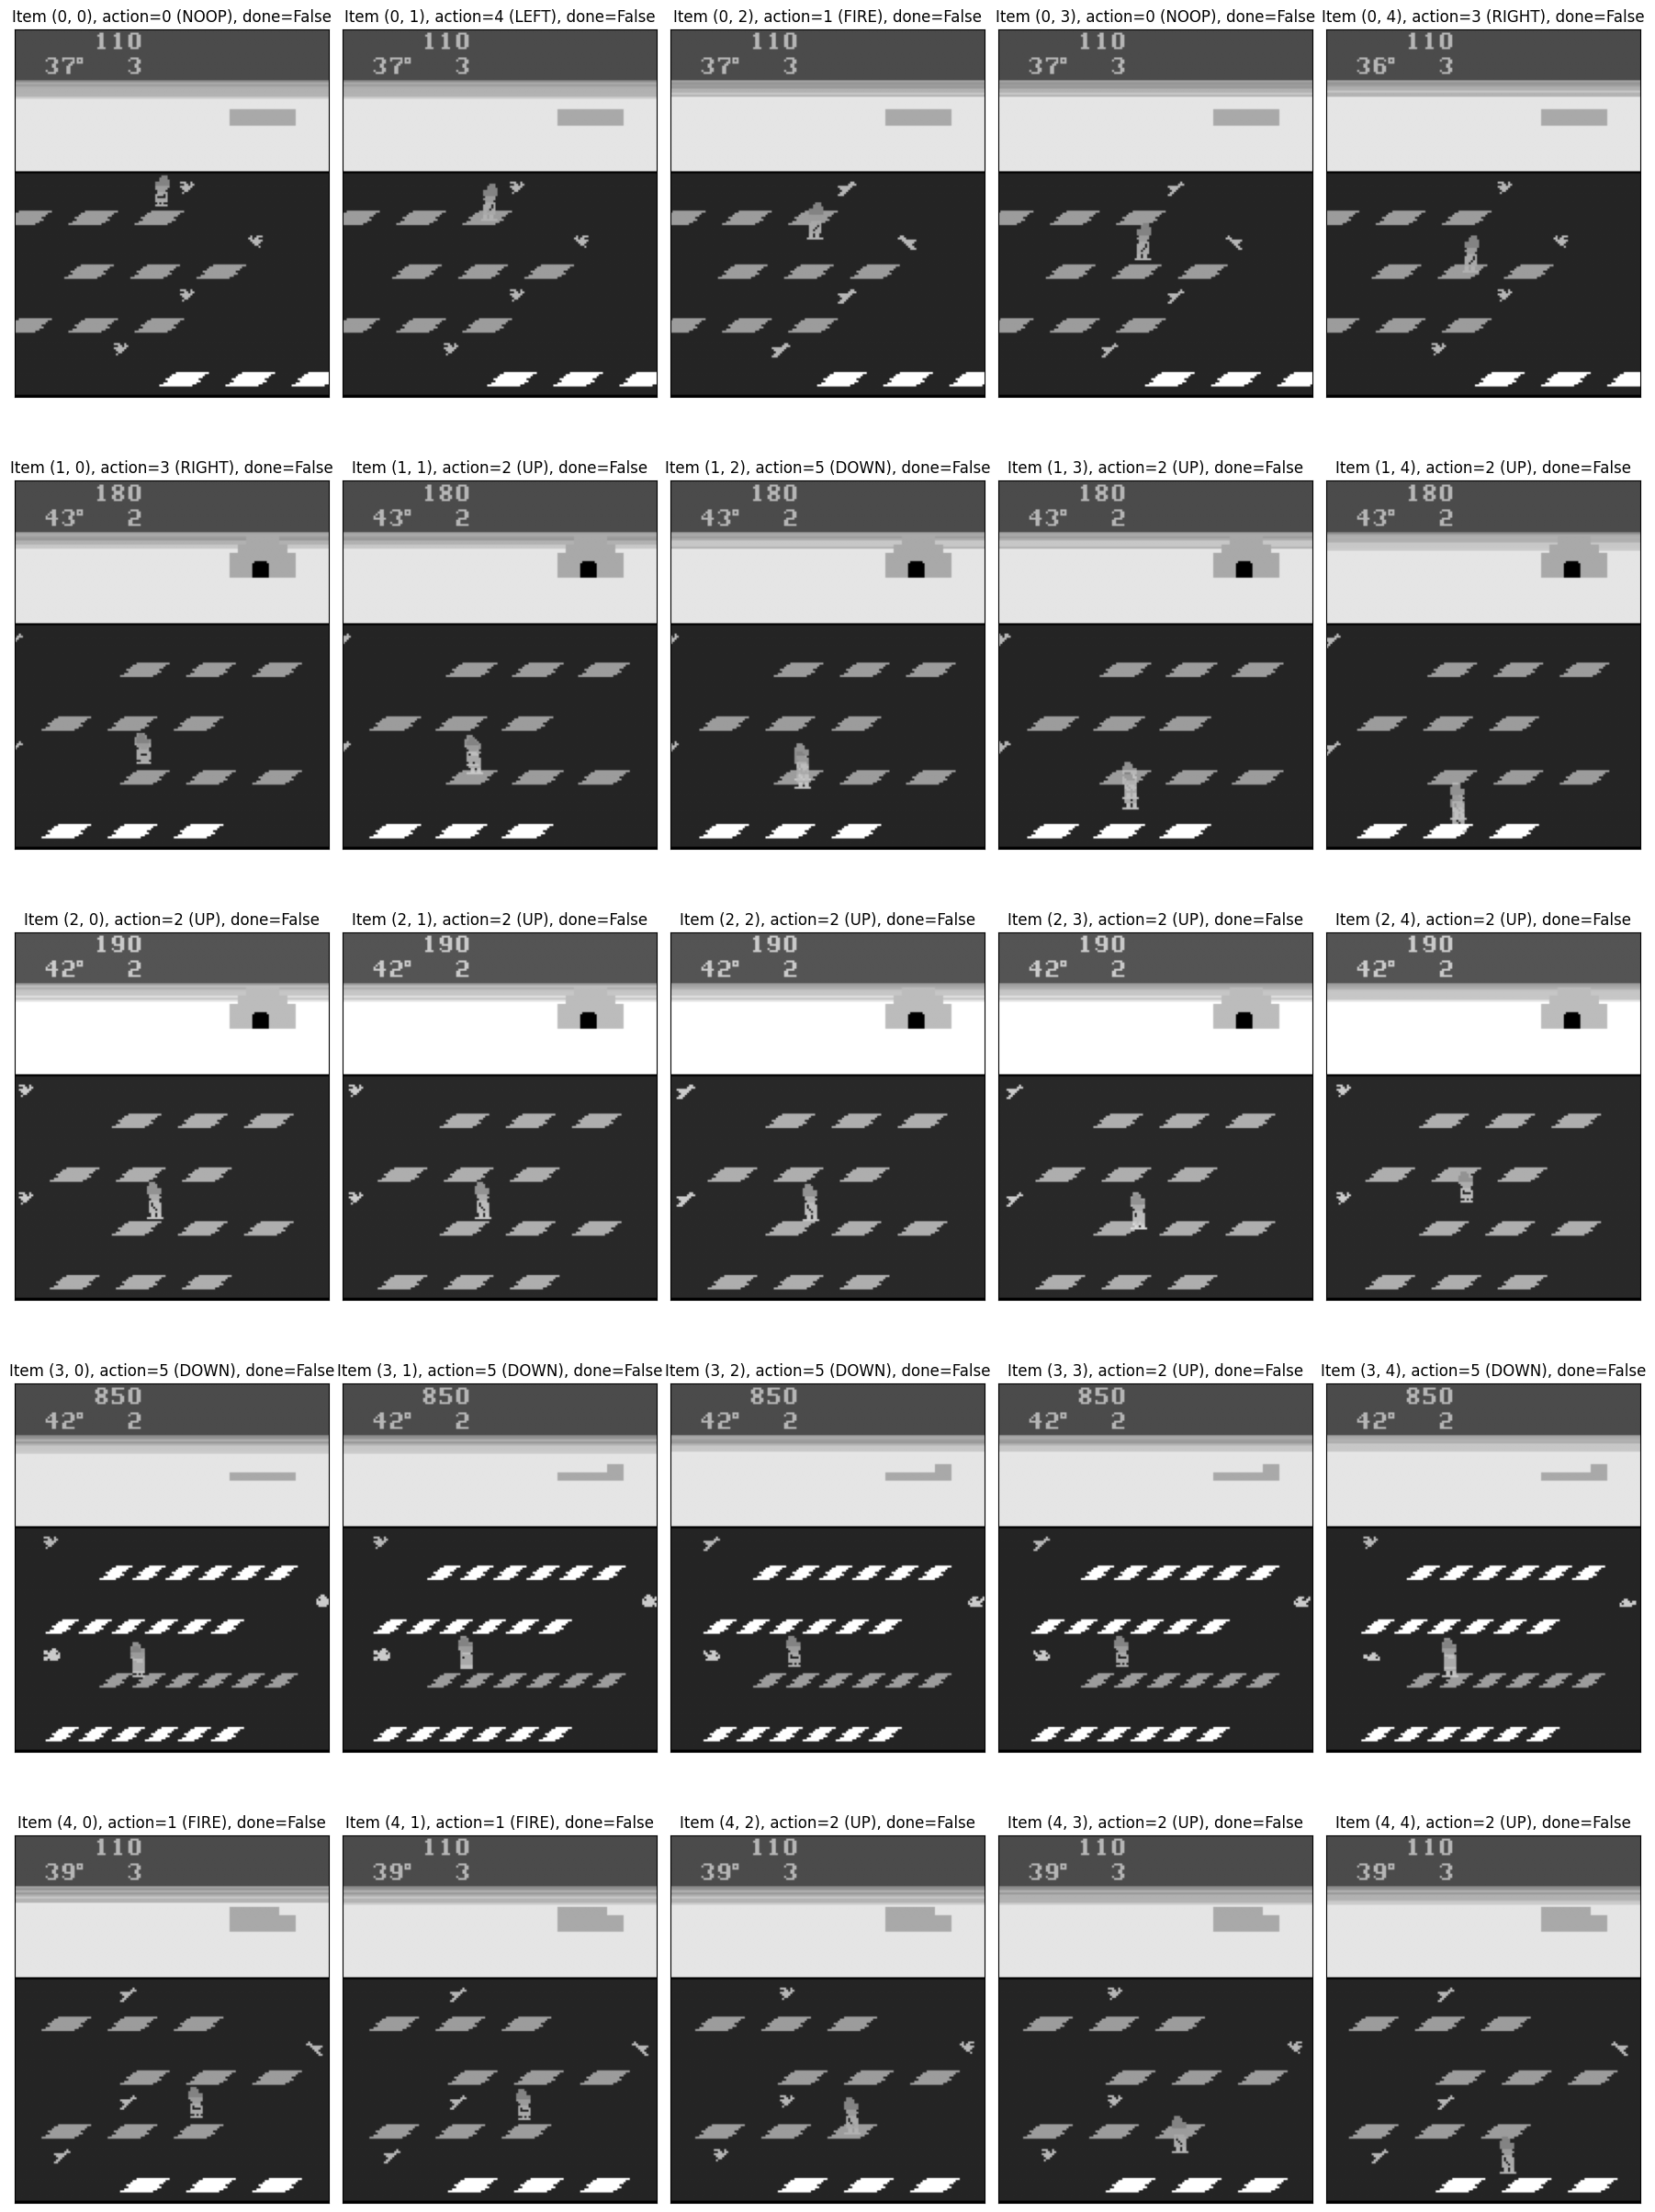

In [153]:
# @launchit.disable
l = len(RT.render_test_batch.obs)
s = RT.render_test_batch.obs.shape[1]
fig, axes = plt.subplots(l, s)
fig.set_figwidth(18)
fig.set_figheight(5 * len(axes))

for i, (pmasks, obs, actions, dones) in enumerate(zip(RT.render_test_batch.pmasks, RT.render_test_batch.obs, RT.render_test_batch.actions, RT.render_test_batch.dones)):
    for j, ax in enumerate(axes[i]):
        kwargs = dict(cmap='gray')
        action_name = ale_py.Action(actions[j].item()).name
        ax.set_title(f'Item {i,j}, action={actions[j]} ({action_name}), done={dones[j].bool()}')
        ax.imshow(obs[j].squeeze(0).cpu(), **kwargs)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()

# WorldModel

In [154]:
# @launchit.collect_export
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF
from torch.nn.attention import SDPBackend, sdpa_kernel

## VisionHead

In [155]:
# @launchit.collect_export
class VisionHead(nn.Module):
    @dataclass(slots=True)
    class Params:
        input_shape: tuple = (1, 178, 152)
        grid: tuple = None # output features grid
        features_counts: tuple = None # how many output features per CNN layer
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        self.params.input_shape = tuple(params.input_shape)
        self.params.grid = tuple(params.grid)
        self.params.features_counts = tuple(params.features_counts)

        if self.params.input_shape == (1, 178, 152) or self.params.input_shape == (1, 178, 178):
            assert len(self.params.features_counts) == 4, len(self.params.features_counts)

            if self.params.grid == (6, 6):
                self.cnn = nn.Sequential(
                    nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 87, 74)
                    nn.BatchNorm2d(self.params.features_counts[0]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 42, 35)
                    nn.BatchNorm2d(self.params.features_counts[1]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=3, stride=2, padding=0), # -> (fc[2], 20, 17)
                    nn.BatchNorm2d(self.params.features_counts[2]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[2], self.params.features_counts[3], kernel_size=3, stride=2, padding=0), # -> (fc[3], 9, 8)
                    nn.ReLU(),
                    
                    nn.AdaptiveAvgPool2d(self.params.grid),
                )
            elif self.params.grid == (7, 7):
                self.cnn = nn.Sequential(
                    nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 87, 74)
                    nn.BatchNorm2d(self.params.features_counts[0]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 42, 35)
                    nn.BatchNorm2d(self.params.features_counts[1]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=3, stride=2, padding=0), # -> (fc[2], 20, 17)
                    nn.BatchNorm2d(self.params.features_counts[2]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[2], self.params.features_counts[3], kernel_size=3, stride=2, padding=0), # -> (fc[3], 9, 8)
                    nn.ReLU(),
    
                    nn.AdaptiveAvgPool2d(self.params.grid),
                )
            elif self.params.grid == (9, 9):
                self.cnn = nn.Sequential(
                    nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 87, 74)
                    nn.BatchNorm2d(self.params.features_counts[0]),
                    nn.ReLU(),
                    
                    # Layer 2: 87x74 -> 42x35
                    nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 42, 35)
                    nn.BatchNorm2d(self.params.features_counts[1]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=3, stride=2, padding=0), # -> (fc[2], 20, 17)
                    nn.BatchNorm2d(self.params.features_counts[2]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[2], self.params.features_counts[3], kernel_size=3, stride=1, padding=0),  # -> (fc[3], 18, 15)
                    nn.ReLU(),
                    
                    nn.AdaptiveAvgPool2d(self.params.grid),
                )
        elif self.params.input_shape == (1, 45, 45) and self.params.grid == (5, 5):
            assert len(self.params.features_counts) == 3, len(self.params.features_counts)
            self.cnn = nn.Sequential(
                nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 21, 21), detect raw edges/shapes
                nn.BatchNorm2d(self.params.features_counts[0]),
                nn.ReLU(),
                
                nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 9, 9), detect mid-level motion paths
                nn.BatchNorm2d(self.params.features_counts[1]),
                nn.ReLU(),
                
                nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=5, stride=1, padding=0), # -> (fc[2], 5, 5), shape extraction
                nn.ReLU(),
            )
        else:
            assert False, f'Unsupported {params.input_shape=}'

        self.out_tokens_count = math.prod(self.params.grid)
        self.out_features_count = self.params.features_counts[-1]

    def forward(self, x):
        x_shape = x.shape
        x = x.view(-1, *x.shape[-3:]) # (uberbatch, color, height, width)
        features = self.cnn(x) # (uberbatch, out_features_count, grid[0], grid[1]) 
        return features.view(*x_shape[:-3], self.out_features_count, *self.params.grid)

## RenderHead

### LinearProjector

In [156]:
# @launchit.collect_export
class LinearProjector(nn.Module):
    @dataclass(slots=True)
    class Params:
        d_model: int = 256
        out_dims_count: int = None
        
    def __init__(self, params):
        super().__init__()
        self.linear = nn.Linear(params.d_model, params.out_dims_count)

    ForwardResult = namedtuple('ForwardResult', 'y, reg_losses')

    def forward(self, x):
        return self.ForwardResult(y=self.linear(x), reg_losses={})

### DreamerProjector

In [157]:
# @launchit.collect_export
class DreamerProjector(nn.Module):
    @dataclass(slots=True)
    class Params:
        d_model: int = 256
        groups_count: int = 32
        classes_count: int = 8
        out_dims_count: int = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        self.internal_dims_count = self.params.groups_count * self.params.classes_count
        self.logits_maker = nn.Linear(self.params.d_model, self.internal_dims_count)
        self.out_maker = nn.Linear(self.internal_dims_count, self.params.out_dims_count)

    ForwardResult = namedtuple('ForwardResult', 'y, reg_losses')

    def forward(self, x, temperature=1.0):
        x_shape = x.shape
        logits = self.logits_maker(x) # (..., out_dims_count)
        logits = logits.view(*x.shape[:-1], self.params.groups_count, self.params.classes_count) # (..., groups, classes)
        reg_losses = {}

        if self.training:
            # KL-loss versus uniform distr
            probs = F.softmax(logits, dim=-1)
            reg_losses['DreamerProjector.kl_loss'] = probs * (torch.log(probs + 1e-8) - torch.log(torch.tensor(1.0 / self.params.classes_count)))
            
            # Gumbel-Softmax allows gradients to flow through discrete sampling
            # hard=True forces the forward pass to be strict 1s and 0s (one-hot)
            latents = F.gumbel_softmax(logits, tau=temperature, hard=True, dim=-1)
        else:
            # Test time: just take the most likely category (argmax)
            indices = logits.argmax(dim=-1)
            latents = F.one_hot(indices, num_classes=self.params.classes_count).float()
            
        latents = latents.view(*x.shape[:-1], self.internal_dims_count) # (..., internal_dims_count)
        return self.ForwardResult(
            y=self.out_maker(latents), # (..., out_dims_count)
            reg_losses=reg_losses,
        )       

### RenderHead

In [235]:
# @launchit.collect_export
class RenderHead(nn.Module):
    @dataclass(slots=True)
    class Params:
        ob_shape: tuple = (1, 178, 152)
        d_model: int = 256
        projector: dict = None
        render_engine: dict = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        assert self.params.ob_shape == (1, 178, 152), f'Unsupported {self.params.ob_shape=}'

        match self.params.render_engine['type']:
            case 'layer': self.create_layer_render_engine()
            case 'block': self.create_block_render_engine()
            case _: assert False, f'Unsupported {self.params.render_engine['type']=}'    

        if self.params.projector['type'] == 'linear':
            projector_params = DreamerProjector.Params(
                d_model=self.params.d_model,
                out_dims_count=math.prod(self.subrenderer_input_shape),
            )
            self.projectors = nn.ModuleList([
                LinearProjector(projector_params) for _ in range(len(self.subrenderers))
            ])
        elif self.params.projector['type'] == 'dreamer':
            projector_params = DreamerProjector.Params(
                d_model=self.params.d_model,
                groups_count=self.params.projector['groups_count'],
                classes_count=self.params.projector['classes_count'],
                out_dims_count=math.prod(self.subrenderer_input_shape),
            )
            self.projectors = nn.ModuleList([
                DreamerProjector(projector_params) for _ in range(len(self.subrenderers))
            ])
        else:
            assert False, f'Unsupported {self.params.projector=}'

        assert len(self.subrenderers) == len(self.projectors)

    def forward(self, lvs):
        # lvs must contain all data sufficient to render observation
        # lvs.shape = (..., d_model)
        assert lvs.shape[-1] == self.params.d_model
        
        if self.params.render_engine['type'] == 'layer':
            return self.layer_forward(lvs)
        elif self.params.render_engine['type'] == 'block':
            return self.block_forward(lvs)
        else:
            assert False, f'Unsupported {self.params.render_engine['type']=}'

    LayerForwardResult = namedtuple('LayerForwardResult', 'logits, contents, gates, alpha_masks, reg_losses')
    BlockForwardResult = namedtuple('BlockForwardResult', 'logits, reg_losses')
    
    def layer_forward(self, lvs):
        lvs_shape = lvs.shape
        lvs = lvs.view(-1, self.params.d_model) # (uberbatch, d_model)
        uberbatch_size = len(lvs)
        contents = []
        gates = []
        reg_losses = {}
        
        # 1. Run the latent code through every subrenderer (expert)
        for projector, subrenderer in zip(self.projectors, self.subrenderers):
            projs = projector(lvs) # (uberbatch, *subrenderer_input_shape)
            
            for k, v in projs.reg_losses.items():
                k = 'RenderHead.' + k
                l = lu.coalesce_fn(reg_losses.get(k, None), lambda x: [x], [])
                reg_losses[k] = torch.cat(l + [v], dim=0)

            features = projs.y
            features = features.view(uberbatch_size, *self.subrenderer_input_shape)
            out = subrenderer(features) 
            out = out.view(uberbatch_size, 2, *self.params.ob_shape)
            contents.append(out[:,0:1]) # Proposed pixel intensities, (uberbatch, 1, *self.params.ob_shape)
            gates.append(out[:,1:2])    # Proposed selection urgency, (uberbatch, 1, *self.params.ob_shape)

        for k, v in reg_losses.items():
            reg_losses[k] = reg_losses[k].sum(dim=-1).mean()

        contents = torch.cat(contents, dim=1) # (uberbatch, subrenderers, *self.params.ob_shape)
        gates = torch.cat(gates, dim=1) # (uberbatch, subrenderers, *self.params.ob_shape)
        assert contents.shape == (uberbatch_size, len(self.subrenderers), *self.params.ob_shape), contents.shape
        assert gates.shape == contents.shape
        
        # 2. Compute Softmax-Gated Alpha Masks across the Layer Dimension
        # This mathematically forces the masks for every single pixel to sum to 1.0.
        # It creates a clean, fully differentiable competitive gate.
        alpha_masks = F.softmax(gates, dim=2)

        # 3. Blending Step: Element-wise multiply content by alpha, then sum across layers
        # This is a fully differentiable weighted average per pixel
        # Note: return raw logits since AMP requires BCEWithLogitsLoss which requires raw logits
        logits = torch.sum(contents * alpha_masks, dim=1) # (uberbatch, 1, *self.params.ob_shape)
        logits_output_shape = (*lvs_shape[:-1], *self.params.ob_shape)
        other_output_shape = (*lvs_shape[:-1], len(self.subrenderers), *self.params.ob_shape)
        return self.LayerForwardResult(
            logits=logits.view(logits_output_shape), 
            contents=contents.view(other_output_shape), 
            gates=gates.view(other_output_shape), 
            alpha_masks=alpha_masks.view(other_output_shape),
            reg_losses=reg_losses,
        )

    def block_forward(self, lvs):
        lvs_shape = lvs.shape
        lvs = lvs.view(-1, self.params.d_model) # (uberbatch, d_model)
        uberbatch_size = len(lvs)
        reg_losses = {}
        interim_canvases = torch.zeros(uberbatch_size, 1, *self.interim_canvas_shape, device=lvs.device)
        
        for projector, subrenderer, landing in zip(self.projectors, self.subrenderers, self.subrenderer_landings):
            projs = projector(lvs) # (uberbatch, *subrenderer_input_shape)
            
            for k, v in projs.reg_losses.items():
                k = 'RenderHead.' + k
                l = lu.coalesce_fn(reg_losses.get(k, None), lambda x: [x], [])
                reg_losses[k] = torch.cat(l + [v], dim=0)

            features = projs.y
            features = features.view(uberbatch_size, *self.subrenderer_input_shape)
            block = subrenderer(features) # (uberbatch, *subrenderer_output_shape)
            _, _, block_h, block_w = block.shape
            interim_canvases[:,:,landing[0]:landing[0]+block_h,landing[1]:landing[1]+block_w] = block

        for k, v in reg_losses.items():
            reg_losses[k] = reg_losses[k].sum(dim=-1).mean()

        hw_shape = self.params.ob_shape[1:] # (1, 178, 152) -> (178, 152)
        logits = VF.center_crop(interim_canvases, hw_shape)
        logits_output_shape = (*lvs_shape[:-1], *self.params.ob_shape)
        return self.BlockForwardResult(
            logits=logits.view(logits_output_shape), 
            reg_losses=reg_losses,
        )
        
    def create_layer_render_engine(self):
        self.subrenderer_input_shape = (64, 11, 9)
        subrenderer = lambda: nn.Sequential(
            nn.ConvTranspose2d(64, 48, kernel_size=4, stride=2, padding=1, output_padding=(0, 1)), # -> (48, 22, 19)
            nn.ReLU(),
            
            nn.ConvTranspose2d(48, 32, kernel_size=4, stride=2, padding=1), # -> (32, 44, 38)
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1, output_padding=(1, 0)), # -> (16, 89, 76)
            nn.ReLU(),
            
            nn.ConvTranspose2d(16, 2, kernel_size=4, stride=2, padding=1), # -> (2, 178, 152) # pixel importance (gate) + pixel instensity (content)
            # no nn.Sigmoid here because of AMP and BCELoss. AMP forces to uses BCEWithLogitsLoss
        )
        self.subrenderers = nn.ModuleList([
            subrenderer() for _ in range(self.params.render_engine['layers_count'])
        ]) 

    def create_block_render_engine(self):
        block_layout = tuple(self.params.render_engine['layout'])
        
        if block_layout == (2, 2):
            self.subrenderer_input_shape = (64, 6, 5)
            subrenderer = lambda: nn.Sequential(
                nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # (6, 5) -> (12, 10)
                nn.BatchNorm2d(32),
                nn.ReLU(),
                
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), # (12, 10) -> (24, 20)
                nn.BatchNorm2d(16),
                nn.ReLU(),
                
                nn.ConvTranspose2d(16, 1, kernel_size=(4, 2), stride=(4, 4), padding=2), # (24, 20) -> (92, 74) 
            )
            block_output_shape = (92, 74)
        elif block_layout == (3, 3):
            self.subrenderer_input_shape = (48, 4, 3)
            subrenderer = lambda: nn.Sequential(
                nn.ConvTranspose2d(48, 32, kernel_size=4, stride=2, padding=0), # (4, 3) -> (10, 8)
                nn.BatchNorm2d(32),
                nn.ReLU(),
                
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=0), # (10, 8) -> (22, 18)
                nn.BatchNorm2d(16),
                nn.ReLU(),
                
                nn.ConvTranspose2d(16, 1, kernel_size=3, stride=3, padding=1), # (22, 18) -> (64, 52)
            )
            block_output_shape = (64, 52)
        elif block_layout == (4, 3):
            self.subrenderer_input_shape = (48, 3, 3)
            subrenderer = lambda: nn.Sequential(
                nn.ConvTranspose2d(48, 32, kernel_size=4, stride=2, padding=0), # (3, 3) -> (8, 8)
                nn.BatchNorm2d(32),
                nn.ReLU(),
                
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=0), # (8, 8) -> (18, 18)
                nn.BatchNorm2d(16),
                nn.ReLU(),
                
                nn.ConvTranspose2d(16, 1, kernel_size=(14, 3), stride=(2, 3), padding=1), # (18, 18) -> (46, 52)
            )
            block_output_shape = (46, 52)
        else:
            assert False, f'Unsupported {block_layout=}'

        blocks_count = math.prod(block_layout)
        self.subrenderers = nn.ModuleList([subrenderer() for _ in range(blocks_count)])
        self.interim_canvas_shape = (block_output_shape[0] * block_layout[0], block_output_shape[1] * block_layout[1])
        self.subrenderer_landings = []
        
        for i in range(block_layout[0]):
            for j in range(block_layout[1]):
                land_i = block_output_shape[0] * i
                land_j = block_output_shape[1] * j
                self.subrenderer_landings.append((land_i, land_j))

### Test

In [238]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device
t.projector_variants = [
    dict(type='linear'),
    dict(type='dreamer', groups_count=32, classes_count=8),
]
t.render_engine_variants = [
    dict(type='layer', layers_count=4),
    dict(type='block', layout=(2, 2)),
    dict(type='block', layout=(3, 3)),
    dict(type='block', layout=(4, 3)),
]

for t.projector in t.projector_variants:
    for t.render_engine in t.render_engine_variants:
        print(f'{t.projector=}, {t.render_engine=}')
        t.params = RenderHead.Params(
            ob_shape=(1, 178, 152),
            d_model=256,
            projector=t.projector,
            render_engine=t.render_engine,
        )
        t.model = RenderHead(t.params).to(t.device)
        print(t.model)
        t.params_count = sum(p.numel() for p in t.model.parameters())
        print(f'{t.params_count=:_}')
        
        t.envs_count = 2
        t.sequence_length = 4
        t.embs = torch.zeros(t.envs_count, t.sequence_length, t.params.d_model).to(t.device)
        print(f'{t.embs.shape=}')
        
        t.fr = t.model(t.embs)
        print(f'{t.fr.logits.shape=}')
        print(f'{t.fr.reg_losses=}')
        print('')

t.projector={'type': 'linear'}, t.render_engine={'type': 'block', 'layout': (4, 3)}
kms@ block_output_shape=(46, 52)
kms@ [(0, 0), (0, 52), (0, 104), (46, 0), (46, 52), (46, 104), (92, 0), (92, 52), (92, 104), (138, 0), (138, 52), (138, 104)]
RenderHead(
  (subrenderers): ModuleList(
    (0-11): 12 x Sequential(
      (0): ConvTranspose2d(48, 32, kernel_size=(4, 4), stride=(2, 2))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2))
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): ConvTranspose2d(16, 1, kernel_size=(14, 3), stride=(2, 3), padding=(1, 1))
    )
  )
  (projectors): ModuleList(
    (0-11): 12 x LinearProjector(
      (linear): Linear(in_features=256, out_features=432, bias=True)
    )
  )
)
t.params_count=1_735_308
t.embs.shape=torch.Size([2, 4, 256])
kms@ 

## ReconstructionModel

In [95]:
# @launchit.collect_export
class ReconstructionModel(nn.Module):
    @dataclass(slots=True)
    class Params:
        ob_shape: tuple = (1, 178, 152)
        d_model: int = None
        vision_head: dict = None
        transformer: dict = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        assert isinstance(self.params.ob_shape, (tuple, list)), self.params.ob_shape
        self.params.ob_shape = tuple(params.ob_shape)

        assert self.params.vision_head is not None
        vision_head_params = VisionHead.Params(
            input_shape=self.params.ob_shape,
            grid=self.params.vision_head['grid'],
            features_counts=self.params.vision_head['features_counts'],
        )
        self.vision_head = VisionHead(vision_head_params)
        self.tokens_per_ob = self.vision_head.out_tokens_count
        self.ingress_projector = nn.Linear(self.vision_head.out_features_count, self.params.d_model)
        self.ingress_normalizer = nn.LayerNorm(self.params.d_model)
        self.i_spatial_encoding = nn.Parameter(torch.randn(1, 1, self.vision_head.params.grid[0], 1, self.params.d_model))
        self.j_spatial_encoding = nn.Parameter(torch.randn(1, 1, 1, self.vision_head.params.grid[1], self.params.d_model))
        self.lv_encoding = nn.Parameter(torch.randn(1, 1, self.params.d_model)) 
        self.lvs_count = 1
        self.internal_sequence_length = self.tokens_per_ob + self.lvs_count

        transformer_layer = nn.TransformerEncoderLayer(
            d_model=self.params.d_model, 
            dim_feedforward=self.params.d_model * 4, # kms@ default is 2048, 256 * 4 = 2048
            nhead=self.params.transformer['heads_count'], 
            batch_first=True,
            norm_first=True,  # preferred for RL tasks
            dropout=0.0,      # Dropout destroys RL performance; keep 0.0
        )

        attention_backend_names = lu.when(
            isinstance(self.params.transformer['attention_backend'], str), 
            [self.params.transformer['attention_backend']], 
            self.params.transformer['attention_backend'],
        )
        self.attention_backend = list(map(lambda x: getattr(SDPBackend, x), attention_backend_names))
        self.transformer = nn.TransformerEncoder(
            transformer_layer, 
            num_layers=self.params.transformer['layers_count'],
            enable_nested_tensor=False, # True is incompatible with layers where norm_first=True
            norm=nn.LayerNorm(self.params.d_model), # output normalizer
        )

    @property
    def grad_norm_groups(self):
        groups = dict(
            vision_head=list(self.vision_head.parameters()),
            ingress_projector=list(self.ingress_projector.parameters()),
            spatial_encoding=[self.i_spatial_encoding, self.j_spatial_encoding],
            lv_encoding=[self.lv_encoding],
            transformer=list(self.transformer.parameters()),
        )

        return groups

    def train(self, mode=True):
        # DO NOT call super().train(mode)!!!
        # This is due to issues with strange transformer behavior when: eval mode + torch.no_grad() + attention_mask.
        # See: https://share.google/aimode/lFz0O2Qgduhc185Zt
        self.vision_head.train(mode)

    ForwardResult = namedtuple('ForwardResult', 'recon')

    def forward(self, obs):
        # obs.shape = (batch, seq, color, height, width)
        batch_size = len(obs)
        seq_len = obs.shape[1]

        # EMBED input data
        x = self.embed_input_data(obs) # (batch, seq, tokens, d_model)
        assert x.shape == (batch_size, seq_len, self.tokens_per_ob, self.params.d_model), x.shape

        # ATTACH LV to x
        x = x.view(-1, self.tokens_per_ob, self.params.d_model)
        assert x.shape == (batch_size * seq_len, self.tokens_per_ob, self.params.d_model), x.shape
        lv_embs = self.lv_encoding.expand(batch_size * seq_len, 1, -1)
        x = torch.cat([x, lv_embs], dim=1) 
        assert x.shape == (batch_size * seq_len, self.internal_sequence_length, self.params.d_model), x.shape
        
        # TRANSFORM: information from x (ob_tokens) is to be extracted into LV
        with sdpa_kernel(self.attention_backend):
            y = self.transformer(
                x, 
                is_causal=False,
            )

        # GET LV embs - they must contain information sufficient to reconstruct obs
        y = y[:,-1]
        y = y.view(batch_size, seq_len, self.params.d_model)
        return self.ForwardResult(recon=y)

    def embed_input_data(self, obs):
        # obs.shape = (batch, seq, color, height, width)
        assert obs.ndim == 5, obs.ndim
        assert obs.shape[-3:] == self.vision_head.params.input_shape, (obs.shape[-3:], self.vision_head.params.input_shape)
        batch_size = len(obs)
        seq_len = obs.shape[1]

        if obs.dtype == torch.uint8:
            obs = obs / 255.0
        else:
            assert torch.all((0 <= obs) & (obs <= 1.0))

        features = self.vision_head(obs)
        assert features.shape == (batch_size, seq_len, self.vision_head.out_features_count, self.vision_head.params.grid[0], self.vision_head.params.grid[1]) 
        
        # Turn visual features into embeddings (ob_tokens)
        features = features.permute(0, 1, 3, 4, 2)
        assert features.shape == (batch_size, seq_len, self.vision_head.params.grid[0], self.vision_head.params.grid[1], self.vision_head.out_features_count) 
        embs = self.ingress_projector(features)
        assert embs.shape == (batch_size, seq_len, self.vision_head.params.grid[0], self.vision_head.params.grid[1], self.params.d_model) 
        embs = self.ingress_normalizer(embs)

        # Mark ob tokens with location (spatial) 
        embs += self.i_spatial_encoding
        embs += self.j_spatial_encoding

        embs = embs.view(batch_size, seq_len, -1, self.params.d_model)
        assert embs.shape == (batch_size, seq_len, self.tokens_per_ob, self.params.d_model)
        return embs             

## PredictionModel

In [96]:
# @launchit.collect_export
class PredictionModel(nn.Module):
    @dataclass(slots=True)
    class Params:
        sequence_length: int = None
        actions_count: int = None
        d_model: int = None
        transformer: dict = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        self.temporal_encoding = nn.Parameter(torch.randn(1, self.params.sequence_length, self.params.d_model)) # seq number (0,1,2,3...) -> embedding
        assert self.params.actions_count > 0
        self.action_encoding = nn.Embedding(self.params.actions_count, self.params.d_model)
        self.lv_encoding = nn.Parameter(torch.randn(1, self.params.sequence_length, self.params.d_model))
        self.lvs_count = self.params.sequence_length
        self.internal_sequence_length = self.params.sequence_length + self.lvs_count

        transformer_layer = nn.TransformerEncoderLayer(
            d_model=self.params.d_model, 
            dim_feedforward=self.params.d_model * 4, # kms@ default is 2048, 256 * 4 = 2048
            nhead=self.params.transformer['heads_count'], 
            batch_first=True,
            norm_first=True,  # preferred for RL tasks
            dropout=0.0,      # Dropout destroys RL performance; keep 0.0
        )

        self.register_buffer('attention_mask', self.generate_attention_mask())
        
        attention_backend_names = lu.when(
            isinstance(self.params.transformer['attention_backend'], str), 
            [self.params.transformer['attention_backend']], 
            self.params.transformer['attention_backend'],
        )
        self.attention_backend = list(map(lambda x: getattr(SDPBackend, x), attention_backend_names))
        self.transformer = nn.TransformerEncoder(
            transformer_layer, 
            num_layers=self.params.transformer['layers_count'],
            enable_nested_tensor=False, # True is incompatible with layers where norm_first=True
            norm=nn.LayerNorm(self.params.d_model), # output normalizer
        )

    @property
    def grad_norm_groups(self):
        groups = dict(
            temporal_encoding=[self.temporal_encoding],
            action_encoding=[self.action_encoding],
            lv_encoding=[self.lv_encoding],
            transformer=list(self.transformer.parameters()),
        )

        return groups

    def train(self, mode=True):
        # DO NOT call super().train(mode)!!!
        # This is due to issues with strange transformer behavior when: eval mode + torch.no_grad() + attention_mask.
        # See: https://share.google/aimode/lFz0O2Qgduhc185Zt
        pass

    ForwardResult = namedtuple('ForwardResult', 'pred')

    def forward(self, embs, actions, padding_masks):
        # embs.shape = (batch, seq, d_model)
        # actions.shape = (batch, seq)
        # shape of padding_masks: (batch, seq)
        batch_size = len(embs)
        seq_len = embs.shape[1]
        assert actions.shape == (batch_size, seq_len), actions.shape
        assert padding_masks.shape == (batch_size, seq_len), padding_masks.shape

        # ATTACH LV tokens to embs
        lv_embs = self.lv_encoding.expand(batch_size, -1, -1)
        x = torch.cat([embs, lv_embs], dim=1)
        assert x.shape == (batch_size, self.internal_sequence_length, self.params.d_model), x.shape
        
        # ALIGN padding masks with x
        # embs_embs are not pad masked so add zeros to padding_masks
        padding_masks = torch.cat([padding_masks, torch.zeros(batch_size, self.lvs_count, dtype=padding_masks.dtype, device=padding_masks.device)], dim=1)
        assert padding_masks.shape == (batch_size, self.internal_sequence_length), padding_masks.shape

        # TRANSFORM
        with sdpa_kernel(self.attention_backend):
            y = self.transformer(
                x, 
                src_key_padding_mask=padding_masks,
                mask=self.attention_mask, 
                is_causal=False, # not an ordinary causal mask
            )

        # RESULT is fetched from LV
        y = y[:,-self.lvs_count:]
        return self.ForwardResult(pred=y)

    def generate_attention_mask(self):
        # Blank slate matrix to put attention mask components in
        am = torch.zeros(self.internal_sequence_length, self.internal_sequence_length)

        # Ordinary causal mask for input embs
        input_embs_am = nn.Transformer.generate_square_subsequent_mask(self.params.sequence_length)
        input_embs_am = torch.where(torch.isinf(input_embs_am), 0, 1)
        am[:len(input_embs_am),:len(input_embs_am)] = input_embs_am # top-left square

        # LVs could attent to themselves
        am[len(input_embs_am):,len(input_embs_am):] = torch.eye(self.lvs_count) # bottom-right square
        
        # LVs independently could attend to input embs
        am[len(input_embs_am):,:len(input_embs_am)] = input_embs_am # bottom-left square
        assert torch.all(am[:len(input_embs_am),len(input_embs_am):] == 0), 'Input embs should not attend any LV vars'
        return torch.where(am == 0, -torch.inf, 0) # nn.TransformerEncoder expects: 0 - could attent, -inf - couldn't attend

## Test

### Basics: ReconstructionModel

In [97]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device

t.params = ReconstructionModel.Params(
    ob_shape=(1, 178, 152),
    d_model=256,
    vision_head=dict(grid=(6,6), features_counts=(16, 32, 64, 128)),
    transformer=dict(layers_count=4, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
)
t.model = ReconstructionModel(t.params).to(t.device)
print(t.model)
t.params_count = sum(p.numel() for p in t.model.parameters())
print(f'{t.params_count=:_}')

t.envs_count = 2
t.sequence_length = 4
t.obs = torch.zeros(t.envs_count, t.sequence_length, *t.params.ob_shape, dtype=torch.uint8).to(t.device)
print(f'{t.obs.shape=}')

t.fr = t.model(t.obs)
print(f'{t.fr.recon.shape=}')
assert t.fr.recon.shape == (t.envs_count, t.sequence_length, t.params.d_model)

ReconstructionModel(
  (vision_head): VisionHead(
    (cnn): Sequential(
      (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
      (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(6, 6))
    )
  )
  (ingress_projector): Linear(in_features=128, out_features=256, bias=True)
  (ingress_normalizer): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x

### Basics: PredictionModel

In [98]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device

t.params = PredictionModel.Params(
    sequence_length=4,
    actions_count=6,
    d_model=256,
    transformer=dict(layers_count=4, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
)
t.model = PredictionModel(t.params).to(t.device)
print(t.model)
t.params_count = sum(p.numel() for p in t.model.parameters())
print(f'{t.params_count=:_}')

t.envs_count = 2
t.embs = torch.zeros(t.envs_count, t.params.sequence_length, t.params.d_model).to(t.device)
t.pmasks = torch.zeros(t.envs_count, t.params.sequence_length).to(t.device)
t.actions = torch.zeros(t.envs_count, t.params.sequence_length, dtype=torch.int).to(t.device)
print(f'{t.embs.shape=}')
print(f'{t.actions.shape=}')

t.fr = t.model(t.embs, t.actions, t.pmasks)
print(f'{t.fr.pred.shape=}')
assert t.fr.pred.shape == (t.envs_count, t.params.sequence_length, t.params.d_model)

PredictionModel(
  (action_encoding): Embedding(6, 256)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  )
)
t.params_count=3_163_136
t.embs.shape=torch.Size([2, 4, 256])
t.actions.shape=torch.Size([2, 4])
t.fr.pred.shape=torch.Size([2, 4, 2

### PredictionModel.attention_mask

In [99]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device

t.params = PredictionModel.Params(
    sequence_length=4,
    actions_count=6,
    d_model=256,
    transformer=dict(layers_count=4, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
)
t.model = PredictionModel(t.params).to(t.device)
t.am = torch.where(t.model.attention_mask == 0, 1, 0)
t.am

tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 1, 0, 0, 0],
        [1, 1, 0, 0, 0, 1, 0, 0],
        [1, 1, 1, 0, 0, 0, 1, 0],
        [1, 1, 1, 1, 0, 0, 0, 1]])

### grad_norm_groups

In [100]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device

t.params = ReconstructionModel.Params(
    ob_shape=(1, 178, 152),
    d_model=256,
    vision_head=dict(grid=(6,6), features_counts=(16, 32, 64, 128)),
    transformer=dict(layers_count=4, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
)
t.model = ReconstructionModel(t.params).to(t.device)
t.model.grad_norm_groups.keys()

dict_keys(['vision_head', 'ingress_projector', 'spatial_encoding', 'lv_encoding', 'transformer'])

In [101]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device

t.params = PredictionModel.Params(
    sequence_length=4,
    actions_count=6,
    d_model=256,
    transformer=dict(layers_count=4, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
)
t.model = PredictionModel(t.params).to(t.device)
t.model.grad_norm_groups.keys()

dict_keys(['temporal_encoding', 'action_encoding', 'lv_encoding', 'transformer'])

## WorldModel

In [102]:
# @launchit.collect_export
class WorldModel(nn.Module):
    @dataclass(slots=True)
    class Params:
        sequence_length: int = None
        actions_count: int = None
        ob_shape: tuple = (1, 178, 152)
        d_model: int = None
        vision_head: dict = None
        transformer: dict = None
        render_head: dict = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        assert isinstance(self.params.ob_shape, (tuple, list)), self.params.ob_shape
        self.params.ob_shape = tuple(params.ob_shape)
        assert self.params.sequence_length >= 1, self.params.sequence_length
        assert self.params.actions_count > 0, self.params.actions_count

        reconstruction_model_params = ReconstructionModel.Params(
            ob_shape=self.params.ob_shape,
            vision_head=self.params.vision_head,
            d_model=self.params.d_model,
            transformer=self.params.transformer,
        )
        self.reconstruction_model = ReconstructionModel(reconstruction_model_params)

        prediction_model_params = PredictionModel.Params(
            sequence_length=self.params.sequence_length,
            actions_count=self.params.actions_count,
            d_model=self.params.d_model,
            transformer=self.params.transformer,
        )
        self.prediction_model = PredictionModel(prediction_model_params)
        self.p2r_translator = nn.Sequential(
            nn.Linear(self.params.d_model, self.params.d_model * 2),
            nn.ReLU(),
            nn.Linear(self.params.d_model * 2, self.params.d_model),
        )

        render_head_params = RenderHead.Params(
            ob_shape=self.params.ob_shape,
            d_model=self.params.d_model,
            projector=self.params.render_head['projector'],
            render_engine=self.params.render_head['render_engine'],
        )
        self.render_head = RenderHead(render_head_params)

    @property
    def grad_norm_groups(self):
        groups = dict(
            reconstruction_model=list(self.reconstruction_model.parameters()),
            prediction_model=list(self.prediction_model.parameters()),
            p2r_translator=list(self.p2r_translator.parameters()),
            render_head=list(self.render_head.parameters()),
        )

        return groups

    ForwardResult = namedtuple('ForwardResult', 'recon, pred, render_data, reg_losses')

    def forward(self, obs, actions, padding_masks):
        # obs.shape = (batch, seq, color, height, width)
        # actions.shape = (batch, seq)
        # shape of padding_masks: (batch, seq)
        batch_size = len(obs)
        seq_len = obs.shape[1]

        # ANALYZE observations, get structure
        recon = self.reconstruction_model(obs)
        assert recon.recon.shape == (batch_size, seq_len, self.params.d_model)

        # ANALYZE structure, predict dynamics
        pred = self.prediction_model(recon.recon, actions, padding_masks)
        assert pred.pred.shape == (batch_size, seq_len, self.params.d_model)

        # RENDER 
        recon = recon.recon.reshape(-1, self.params.d_model)
        pred = pred.pred.reshape(-1, self.params.d_model)
        translated_pred = self.p2r_translator(pred)
        lvs = torch.cat([recon, translated_pred], dim=0)
        assert lvs.shape == (2 * batch_size * seq_len, self.params.d_model)
        lvs = lvs.view(2, batch_size, seq_len, self.params.d_model)
        render_data = self.render_head(lvs) # (2, batch_size, seq_len, *ob_shape)
        assert render_data.logits.shape == (2, batch_size, seq_len, *self.params.ob_shape)

        # RESULT
        return self.ForwardResult(
            recon=render_data.logits[0], 
            pred=render_data.logits[1], 
            render_data=render_data,
            reg_losses=render_data.reg_losses,
        )               

## Test

### Basics

In [103]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device
# t.device = 'cpu'

t.wmp = WorldModel.Params(
    sequence_length=4,
    actions_count=6,
    ob_shape=(1, 178, 152),
    d_model=256,
    vision_head=dict(grid=(6,6), features_counts=(16, 32, 64, 128)),
    transformer=dict(layers_count=3, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
    render_head=dict(projector=dict(type='linear'), render_engine=dict(type='layer', layers_count=1)),
)
t.model = WorldModel(t.wmp).to(t.device)
print(t.model)
t.params_count = sum(p.numel() for p in t.model.parameters())
print(f'{t.params_count=:_}')

t.envs_count = 2

t.obs = torch.zeros(t.envs_count, t.wmp.sequence_length, *t.wmp.ob_shape, dtype=torch.uint8).to(t.device)
t.actions = torch.zeros(t.envs_count, t.wmp.sequence_length, dtype=torch.int).to(t.device)
t.pmasks = torch.zeros(t.envs_count, t.wmp.sequence_length).to(t.device)

print(f'{t.obs.shape=}')
print(f'{t.pmasks.shape=}')
print(f'{t.actions.shape=}')

t.fr = t.model(t.obs, t.actions, t.pmasks)
print(f'{t.fr.recon.shape=}')
print(f'{t.fr.pred.shape=}')

print(f'{t.fr.render_data.logits.shape=}')
print(f'{t.fr.render_data.contents.shape=}')
print(f'{t.fr.render_data.gates.shape=}')
print(f'{t.fr.render_data.alpha_masks.shape=}')

WorldModel(
  (reconstruction_model): ReconstructionModel(
    (vision_head): VisionHead(
      (cnn): Sequential(
        (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU()
        (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
        (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (8): ReLU()
        (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
        (10): ReLU()
        (11): AdaptiveAvgPool2d(output_size=(6, 6))
      )
    )
    (ingress_projector): Linear(in_features=128, out_features=256, bias=True)
    (ingress_normalizer): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (

## Configure

In [204]:
# @launchit.disable
# @launchit.collect
HP.model.parent = None
HP.model.sequence_length = 4
HP.model.actions_count = 6
HP.model.ob_shape = (1, 178, 152)
HP.model.d_model = 256
HP.model.vision_head = dict(grid=(6,6), features_counts=(16, 32, 64, 128))
HP.model.transformer = dict(layers_count=3, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH'])
HP.model.render_head = dict(projector=dict(type='linear'), render_engine=dict(type='layer', layers_count=4))
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'general': {'comment': None,
             'random_seed': 26,
             'is_torch_deterministic': True,
             'is_torch_compile': True,
             'is_torch_amp': True},
 'dataset': {'train': ['train_dataset:100',
                       'train_dataset:101',
                       'train_dataset:102',
                       'train_dataset:103',
                       'train_dataset:104',
                       'train_dataset:105',
                       'train_dataset:106',
                       'train_dataset:107',
                       'train_dataset:108',
                       'train_dataset:109'],
             'test': 'test_dataset:2'},
 'model': {'parent': None,
           'sequence_length': 4,
           'actions_count': 6,
           'ob_shape': (1, 178, 152),
           'd_model': 256,
           'vision_head': {'grid': (6, 6),
                           'features_counts': (16, 32, 64, 128)}

## Initrd

In [205]:
# @launchit.collect_initrd
# @launchit.disable
if type(CONFIG).__name__ == 'BuildConfig' and HP.model.parent:
    coords = hp_parse_artifact_source(HP.model.parent)
    CONFIG.artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_ext='json', asset_classifier='world_model_params', maven_group_id=coords.group_id)
    CONFIG.artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_ext='pt', asset_classifier='world_model', maven_group_id=coords.group_id)
# @launchit.stop

## Create

In [206]:
wmp = WorldModel.Params(
    sequence_length=HP.model.sequence_length,
    actions_count=HP.model.actions_count,
    ob_shape=HP.model.ob_shape,
    d_model=HP.model.d_model,
    vision_head=HP.model.vision_head,
    transformer=HP.model.transformer,
    render_head=HP.model.render_head,
)

RT.world_model = WorldModel(wmp).to(CONFIG.cuda_device)
LOG(f'WorldModel created')

if HP.general.is_torch_compile:
    RT.world_model = torch.compile(RT.world_model, fullgraph=True)
    LOG(f'WorldModel compiled') 
    
if HP.model.parent is not None:
    coords = hp_parse_artifact_source(HP.model.parent)
    assert coords.model_name in ('18d_world_model_02', '18d_world_model_03'), coords.model_name
    model_weights_data = RT.artifact_registry.get_asset_content(
        coords.model_name, coords.model_version, asset_ext='pt', asset_classifier='world_model', maven_group_id=coords.group_id
    )
    
    with io.BytesIO(model_weights_data) as b:
        kwargs = {}
        
        if not CONFIG.is_cuda:
            kwargs['map_location'] = torch.device('cpu')

        state_dict = torch.load(b, **kwargs)
        
        if coords.model_name == '18d_world_model_02':
            # RenderHead.adapter has been moved to WorldModel.egress_projectors, so need to rename keys manually
            renames = [
                ('_orig_mod.render_heads.${INDEX}.adapter.weight', '_orig_mod.egress_projectors.${INDEX}.weight'),
                ('_orig_mod.render_heads.${INDEX}.adapter.bias', '_orig_mod.egress_projectors.${INDEX}.bias'),
                ('render_heads.${INDEX}.adapter.weight', 'egress_projectors.${INDEX}.weight'),
                ('render_heads.${INDEX}.adapter.bias', 'egress_projectors.${INDEX}.bias'),
            ]
            
            for i in range(len(RT.world_model.render_heads)):
                for rename in renames:
                    source_key = rename[0].replace('${INDEX}', str(i))
                    target_key = rename[1].replace('${INDEX}', str(i))

                    if source_key in state_dict:
                        state_dict[target_key] = state_dict.pop(source_key)

        RT.world_model.load_state_dict(state_dict)

    LOG(f'WorldModel state loaded from "{HP.model.parent}"')    

WorldModel created
WorldModel compiled


# TRAIN

## EdgeDetector

In [33]:
# @launchit.collect_explore
# https://share.google/aimode/910bVkcGs9nvCh9Q8
class EdgeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        # Sobel filters to extract horizontal and vertical edges
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        # Register as buffers so they move to the correct GPU automatically
        self.register_buffer('sobel_x', sobel_x)
        self.register_buffer('sobel_y', sobel_y)

    ForwardResult = namedtuple('ForwardResult', 'grad_x, grad_y, magnitude')    
    
    def forward(self, x):
        # x shape: (Batch, 1, H, W)
        padded = F.pad(x, (1, 1, 1, 1), mode='replicate') # Pad edges to keep sizes matching
        grad_x = F.conv2d(padded, self.sobel_x)
        grad_y = F.conv2d(padded, self.sobel_y)
        magnitude = torch.sqrt(grad_x ** 2 + grad_y ** 2 + 1e-6)
        return EdgeDetector.ForwardResult(grad_x=grad_x, grad_y=grad_y, magnitude=magnitude)

## render_reconstructions

In [32]:
def render_reconstructions(model, batch, edge_detector):
    assert batch.pmasks.sum() == 0, 'Expected no padding sequences in render batch yet'
    assert batch.obs.shape[1] == model.params.sequence_length + 1
    obs = batch.obs[:,:-1] / 255.0

    with torch_utils.eval_mode(model):
        with torch.no_grad():
            mfr = model(
                obs=obs, 
                actions=batch.actions[:,:-1], 
                padding_masks=batch.pmasks[:,:-1],
            )
            reconstr_obs = torch.sigmoid(mfr.recon) # logits -> pixel values
            assert reconstr_obs.shape == obs.shape, (reconstr_obs.shape, obs.shape)
            assert len(reconstr_obs) < 10
    
            obs_cpu = obs.cpu()
            actions_cpu = batch.actions.cpu()
    
            for i in range(len(reconstr_obs)):
                fig, axes = plt.subplots(2, reconstr_obs.shape[1], squeeze=False)
                fig.set_figwidth(16)
                fig.set_figheight(4 * len(axes))
                fig.set_constrained_layout(True)
    
                for j in range(reconstr_obs.shape[1]):
                    cmap_name = 'gray'
                    
                    action = actions_cpu[i,j].item()
                    action_name = ale_py.Action(action).name
                    ob = obs_cpu[i,j]
    
                    axes[0,j].set_title(f'{i,j}, action={action} ({action_name}), done={batch.dones[i,j].int()}', fontdict=dict(fontsize=10))
                    axes[0,j].imshow(ob.squeeze(0), cmap=cmap_name)
                    axes[0,j].set_xticks([])
                    axes[0,j].set_yticks([])
    
                    if j == 0:
                        axes[0,j].set_ylabel('ob', rotation=90, size=12, labelpad=15, verticalalignment='center')
    
                    reconstr_ob = reconstr_obs[i,j]
                    ob = obs[i,j]
                    bce_loss = F.binary_cross_entropy(reconstr_ob, ob)
                    reconstr_edges = edge_detector(reconstr_ob.unsqueeze(0))
                    true_edges = edge_detector(ob.unsqueeze(0))
                    edge_loss = F.mse_loss(reconstr_edges.magnitude, true_edges.magnitude)
                    ssim = piq.ssim(reconstr_ob.unsqueeze(0), ob.unsqueeze(0)).item()
                    
                    axes[1,j].set_title(f'{i,j}, ' + 
                                        f'ssim={ssim:.3f}, ' + 
                                        f'bce={bce_loss.item():.3f}, edge={edge_loss.item():.3f}', fontdict=dict(fontsize=10))
                    axes[1,j].imshow(reconstr_ob.cpu().squeeze(0), cmap=cmap_name)
                    axes[1,j].set_xticks([])
                    axes[1,j].set_yticks([])
    
                    if j == 0:
                        axes[1,j].set_ylabel('reconstr_ob', rotation=90, size=12, labelpad=15, verticalalignment='center')
    
                yield fig, ssim

## render_predictions

In [33]:
def render_predictions(model, batch, edge_detector):
    assert batch.pmasks.sum() == 0, 'Expected no padding sequences in render batch yet'
    assert batch.obs.shape[1] == model.params.sequence_length + 1

    with torch_utils.eval_mode(model):
        with torch.no_grad():
            mfr = model(
                obs=batch.obs[:,:-1] / 255.0,
                actions=batch.actions[:,:-1],
                padding_masks=batch.pmasks[:,:-1],
            )
            true_next_obs = batch.obs[:,1:] / 255.0
            pred_next_obs = torch.sigmoid(mfr.pred) # logits -> pixel values
            assert pred_next_obs.shape == true_next_obs.shape
            assert len(pred_next_obs) < 10
    
            obs = batch.obs.cpu()
            actions = batch.actions.cpu()
    
            for i in range(len(pred_next_obs)):
                fig, axes = plt.subplots(3, pred_next_obs.shape[1])
                fig.set_figwidth(16)
                fig.set_figheight(4 * len(axes))
                fig.set_constrained_layout(True)
    
                for j in range(pred_next_obs.shape[1]):
                    cmap_name = 'gray'
                    
                    action = actions[i,j]
                    action_name = ale_py.Action(action.item()).name
                    ob = obs[i,j]
                    
                    axes[0,j].set_title(f'{i,j}, action={action} ({action_name}), done={batch.dones[i,j].int()}', fontdict=dict(fontsize=10))
                    axes[0,j].imshow(ob.squeeze(0), cmap=cmap_name)
                    axes[0,j].set_xticks([])
                    axes[0,j].set_yticks([])
    
                    if j == 0:
                        axes[0,j].set_ylabel('ob', rotation=90, size=12, labelpad=15, verticalalignment='center')
                    
                    true_next_ob = true_next_obs[i,j]
                    bce_loss = F.binary_cross_entropy(true_next_ob, true_next_ob)
                    true_edges = edge_detector(true_next_ob.unsqueeze(0))
                    edge_loss = F.mse_loss(true_edges.magnitude, true_edges.magnitude)
                    
                    axes[1,j].set_title(f'{i,j}, bce={bce_loss.item():.3f}, edge={edge_loss.item():.3f}, done={batch.dones[i,j+1].int()}', fontdict=dict(fontsize=10))
                    axes[1,j].imshow(true_next_ob.cpu().squeeze(0), cmap=cmap_name)
                    axes[1,j].set_xticks([])
                    axes[1,j].set_yticks([])
    
                    if j == 0:
                        axes[1,j].set_ylabel('true_next_ob', rotation=90, size=12, labelpad=15, verticalalignment='center')
    
                    pred_next_ob = pred_next_obs[i,j]
                    bce_loss = F.binary_cross_entropy(pred_next_ob, true_next_ob)
                    pred_edges = edge_detector(pred_next_ob.unsqueeze(0))
                    true_edges = edge_detector(true_next_ob.unsqueeze(0))
                    edge_loss = F.mse_loss(pred_edges.magnitude, true_edges.magnitude)
                    ssim = piq.ssim(pred_next_ob.unsqueeze(0), true_next_ob.unsqueeze(0)).item()
                    
                    axes[2,j].set_title(f'{i,j}, ' + 
                                        f'ssim={ssim:.3f}, ' + 
                                        f'bce={bce_loss.item():.3f}, edge={edge_loss.item():.3f}', fontdict=dict(fontsize=10))
                    axes[2,j].imshow(pred_next_ob.cpu().squeeze(0), cmap=cmap_name)
                    axes[2,j].set_xticks([])
                    axes[2,j].set_yticks([])
    
                    if j == 0:
                        axes[2,j].set_ylabel('pred_next_ob', rotation=90, size=12, labelpad=15, verticalalignment='center')
    
                yield fig, ssim

## Configure

In [207]:
# @launchit.disable
# @launchit.collect
HP.train.epochs_count = 4
HP.train.batch_size = 128
HP.train.optimizer = 'AdamW'
HP.train.max_grad_norm = 1.0
HP.train.learn_rate = 'const(0.0005)'
HP.train.bce_loss_coef = 'const(1.0)'
HP.train.edge_loss_coef = 'const(1.0)'
HP.train.recon_loss_coef = 'const(1.0)'
HP.train.pred_loss_coef = 'const(1.0)'
HP.train.reg_loss_coefs = {'RenderHead.DreamerProjector.kl_loss': 0.1}
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'general': {'comment': None,
             'random_seed': 26,
             'is_torch_deterministic': True,
             'is_torch_compile': True,
             'is_torch_amp': True},
 'dataset': {'train': ['train_dataset:100',
                       'train_dataset:101',
                       'train_dataset:102',
                       'train_dataset:103',
                       'train_dataset:104',
                       'train_dataset:105',
                       'train_dataset:106',
                       'train_dataset:107',
                       'train_dataset:108',
                       'train_dataset:109'],
             'test': 'test_dataset:2'},
 'model': {'parent': None,
           'sequence_length': 4,
           'actions_count': 6,
           'ob_shape': (1, 178, 152),
           'd_model': 256,
           'vision_head': {'grid': (6, 6),
                           'features_counts': (16, 32, 64, 128)}

## Create

In [209]:
ump = hp_parse_universal_module(HP.train.optimizer)
assert not ump.args
optimizer = getattr(torch.optim, ump.module_name)(RT.world_model.parameters(), **ump.kwargs)
optimized_params_count = sum(p.numel() for p in RT.world_model.parameters())
LOG(f'{optimized_params_count=:_}')

ump = hp_parse_universal_module(HP.train.learn_rate)
lr_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

ump = hp_parse_universal_module(HP.train.bce_loss_coef)
bce_loss_coef_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

ump = hp_parse_universal_module(HP.train.edge_loss_coef)
edge_loss_coef_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

ump = hp_parse_universal_module(HP.train.recon_loss_coef)
recon_loss_coef_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

ump = hp_parse_universal_module(HP.train.pred_loss_coef)
pred_loss_coef_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

optimized_params_count=11_992_296


In [36]:
edge_detector = EdgeDetector()
edge_detector = edge_detector.to(CONFIG.cuda_device)

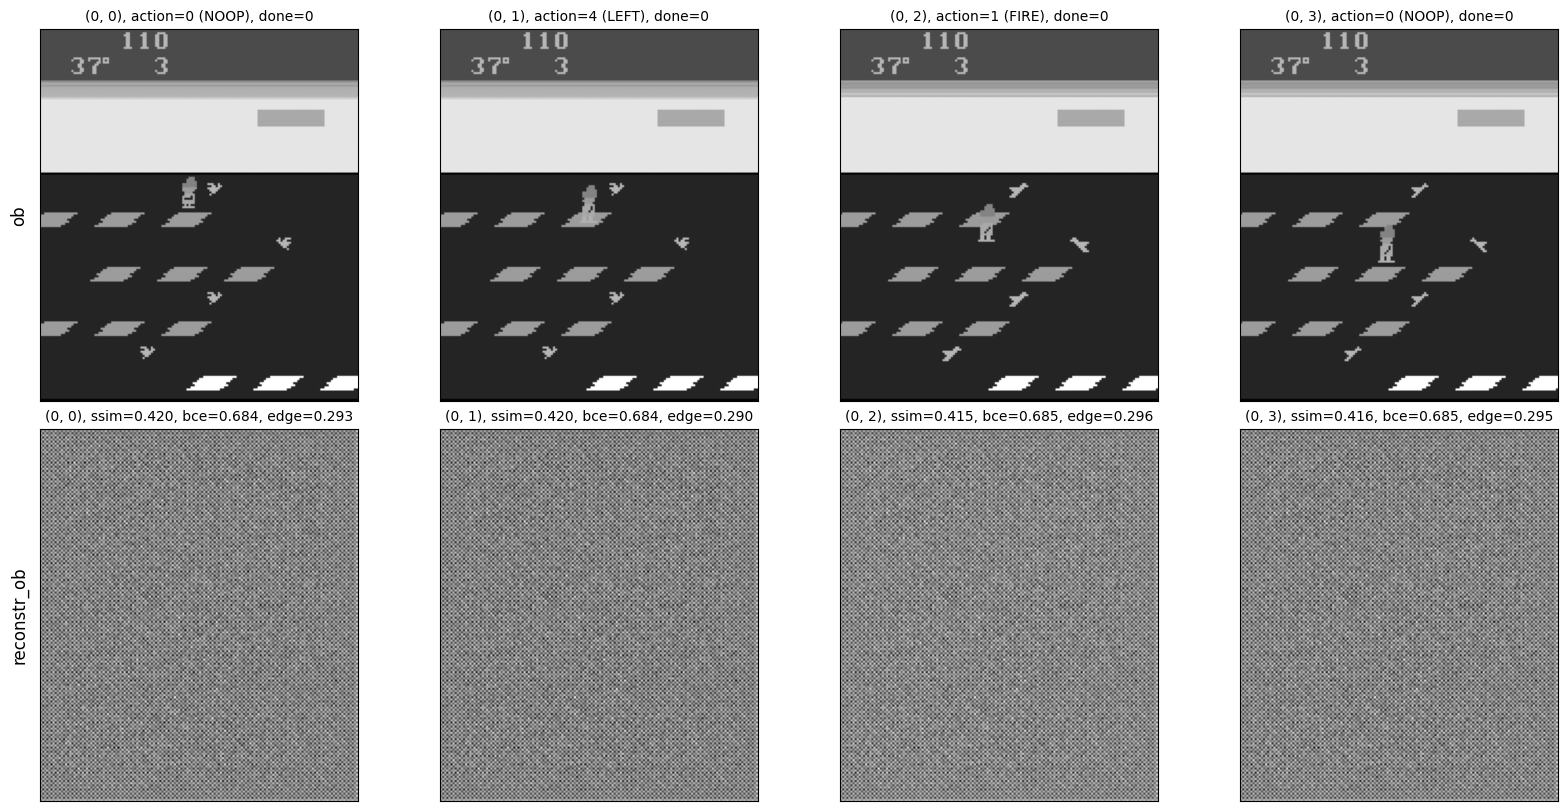

In [37]:
# @launchit.disable
for fig, _ in render_reconstructions(RT.world_model, RT.render_test_batch, edge_detector=edge_detector):
    break

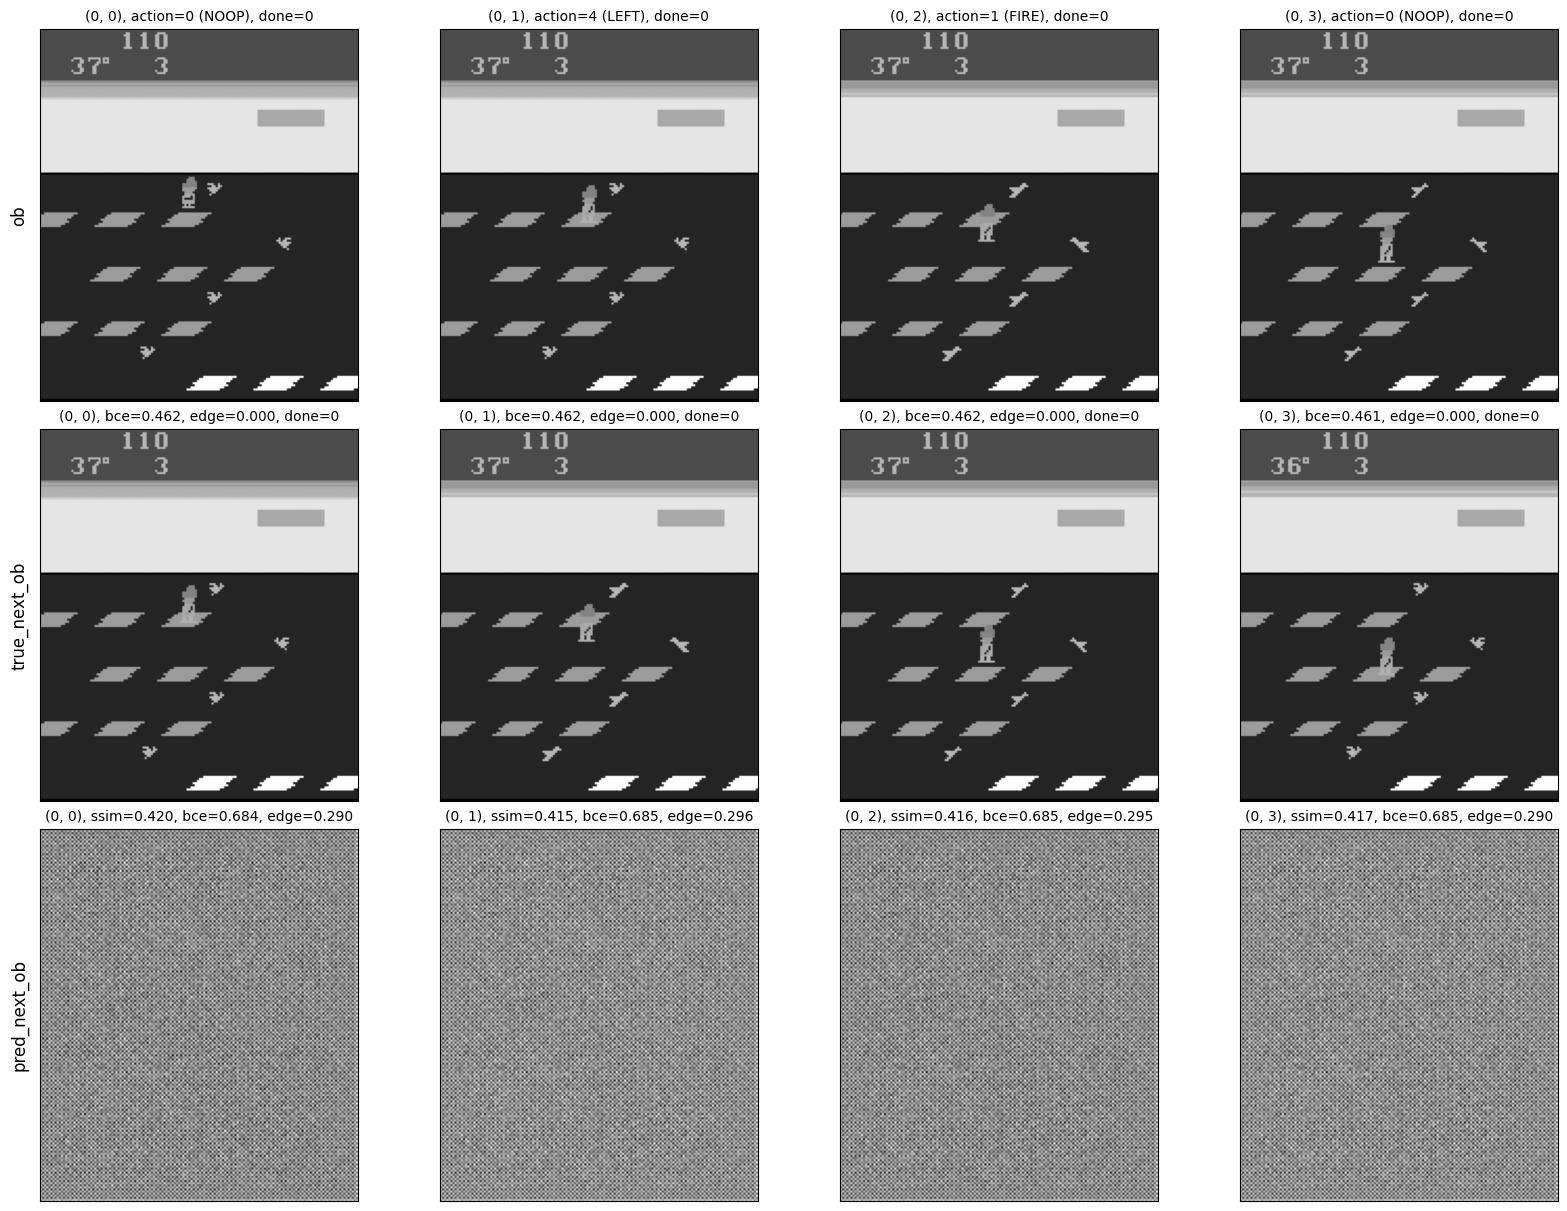

In [38]:
# @launchit.disable
for fig, _ in render_predictions(RT.world_model, RT.render_test_batch, edge_detector=edge_detector):
    break

## Train

In [ ]:
metrics_suite = defaultdict(list)
timings = {}
processed_batch_items = 0
test_dataset = load_dataset(RT.test_dataset_fname).clone().to(CONFIG.cuda_device)
test_dataset.init_iteration(batch_size=HP.train.batch_size, is_shuffled=False)

for epoch in tqdm(range(HP.train.epochs_count), desc='Epoch', disable=not CONFIG.is_interactive):
    old_processed_batch_items = processed_batch_items
    timings.clear()
    t0 = time.monotonic()

    # EXECUTE EXTERNAL COMMANDS
    if command := RT.command_listener.get_command():
        LOG(f'Got {command=}')
        
        if command == 'stop':
            RT.should_save_model = True
            break
        elif command == 'abort':
            RT.should_save_model = False
            break
        else:
            LOG(f'Ignoring unknown {command=}')

    # ANNEAL
    progress = epoch / HP.train.epochs_count
    lr = lr_anneal(progress)
    for param_group in optimizer.param_groups: param_group['lr'] = lr
    bce_loss_coef = bce_loss_coef_anneal(progress)
    edge_loss_coef = edge_loss_coef_anneal(progress)
    recon_loss_coef = recon_loss_coef_anneal(progress)
    pred_loss_coef = pred_loss_coef_anneal(progress)

    t1 = time.monotonic()
    train_dataset_id = RNG.choice(list(RT.train_datasets.keys())).item()
    LOG(f'{train_dataset_id=}', when=not CONFIG.is_interactive)
    train_dataset = load_dataset(RT.train_datasets[train_dataset_id])
    train_dataset = train_dataset.clone().to(CONFIG.cuda_device)
    train_dataset.init_iteration(batch_size=HP.train.batch_size, is_shuffled=True)

    # OPTIMIZATION
    with torch_utils.train_mode(RT.world_model):
        for batch in tqdm(train_dataset, desc='Train batch', total=train_dataset.batches_count, disable=not CONFIG.is_interactive, leave=False):
            # Important batch items invariants and conditions are highlighted in "rollout: pmasks, obs, actions, dones"
    
            # Need at least one obs for prediction, so filter out batch items which don't have enough items
            batch_mask = batch.pmasks.sum(axis=1) < RT.world_model.params.sequence_length
            batch = batch._replace(
                pmasks=batch.pmasks[batch_mask],
                obs=batch.obs[batch_mask],
                actions=batch.actions[batch_mask],
                dones=batch.dones[batch_mask],
            )
            assert len(batch.obs) > 0
    
            with torch.amp.autocast(device_type=CONFIG.cuda_device, dtype=torch.bfloat16, enabled=HP.general.is_torch_amp):
                assert batch.obs.shape[1] - 1 == RT.world_model.params.sequence_length
                batch_size = len(batch.obs)
                obs = batch.obs / 255.0
                input_obs = obs[:,:-1].clone() # all but the last
                pmasks = batch.pmasks[:,:-1]
    
                wmfr = RT.world_model(
                    obs=input_obs, 
                    actions=batch.actions[:,:-1], 
                    padding_masks=pmasks,
                )
                # Get only unpadded obs, unravel first 2 dims to get flat list of images
                flat_masks = ~(pmasks.ravel().bool()) # 2-dim padding masks -> flat presence mask
    
                bce_loss, edge_loss = 0, 0
                recon_bce_loss, recon_edge_loss = 0, 0
                pred_bce_loss, pred_edge_loss = 0, 0
                losses_count = 0
                
                #### RECONSTRUCTION
                recon_obs = wmfr.recon
                assert recon_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                recon_obs = recon_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape)
                recon_obs = recon_obs[flat_masks] # (uberbatch, *ob_shape)
            
                true_obs = input_obs
                assert true_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                true_obs = true_obs.view(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape) # kms@ reshape vs view after input_obs
                true_obs = true_obs[flat_masks] # (uberbatch, *ob_shape)
                
                recon_bce_loss = F.binary_cross_entropy_with_logits(recon_obs, true_obs) # recon_obs contains raw logits, so use BCE with logits!
                recon_edges = edge_detector(torch.sigmoid(recon_obs))
                true_edges = edge_detector(true_obs)
                recon_edge_loss = F.mse_loss(recon_edges.magnitude, true_edges.magnitude)
                
                bce_loss += recon_loss_coef * recon_bce_loss
                edge_loss += recon_loss_coef * recon_edge_loss
                losses_count += 1
                
                #### PREDICTION
                pred_obs = wmfr.pred
                assert pred_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                pred_obs = pred_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape)
                pred_obs = pred_obs[flat_masks] # (uberbatch, *ob_shape)
            
                true_obs = obs[:,1:] # next obs in sequence
                assert true_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                true_obs = true_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape) # kms@ reshape vs view after input_obs
                true_obs = true_obs[flat_masks] # (uberbatch, *ob_shape)
    
                pred_bce_loss = F.binary_cross_entropy_with_logits(pred_obs, true_obs) # pred_obs contains raw logits, so use BCE with logits!
                pred_edges = edge_detector(torch.sigmoid(pred_obs))
                true_edges = edge_detector(true_obs)
                pred_edge_loss = F.mse_loss(pred_edges.magnitude, true_edges.magnitude)
                
                bce_loss += pred_loss_coef * pred_bce_loss
                edge_loss += pred_loss_coef * pred_edge_loss
                losses_count += 1
                
                # 1. Pixel-level Loss (BCE scales cleanly for grayscale classification)/
                bce_loss = bce_loss / losses_count
                # 2. Edge-level Loss (Forces sharp silhouettes for small moving characters)
                edge_loss = edge_loss / losses_count
                
                # Total composite loss
                loss = (bce_loss_coef * bce_loss) + (edge_loss_coef * edge_loss)

                for reg_loss_name, reg_loss_value in wmfr.reg_losses.items():
                    reg_loss_coef = HP.train.reg_loss_coefs[reg_loss_name]
                    loss += reg_loss_coef * reg_loss_value
    
            optimizer.zero_grad()
            loss.backward()
            group_grad_norms = calc_group_grad_norms(RT.world_model)
            grad_norm = lu.when(
                HP.train.max_grad_norm is not None,
                lambda: torch.nn.utils.clip_grad_norm_(RT.world_model.parameters(), max_norm=HP.train.max_grad_norm),
                0
            )
            optimizer.step()
    
            processed_batch_items += batch_size

    LOG(f'Optimization done', when=not CONFIG.is_interactive)
    timings['optimization'] = time.monotonic() - t1

    # FOLLOW-UP optimization (first epoch, last epoch and every 10% of progress)
    if (epoch == 0) or (epoch == HP.train.epochs_count - 1) or (epoch % max(1, (HP.train.epochs_count // 10)) == 0): 
        with torch_utils.eval_mode(RT.world_model): # must have, otherwise running means of BatchNorm could be spoiled
            with torch.no_grad():
                t1 = time.monotonic()
                recon_ssims_sum = torch.tensor(0.0, dtype=torch.float64).to(CONFIG.cuda_device)
                recon_ssims_count = torch.tensor(0, dtype=torch.int).to(CONFIG.cuda_device)
                recon_last_ob_ssims_sum = torch.tensor(0.0, dtype=torch.float64).to(CONFIG.cuda_device)
                recon_last_ob_ssims_count = torch.tensor(0, dtype=torch.int).to(CONFIG.cuda_device)
                pred_ssims_sum = torch.tensor(0.0, dtype=torch.float64).to(CONFIG.cuda_device)
                pred_ssims_count = torch.tensor(0, dtype=torch.int).to(CONFIG.cuda_device)
                pred_last_ob_ssims_sum = torch.tensor(0.0, dtype=torch.float64).to(CONFIG.cuda_device)
                pred_last_ob_ssims_count = torch.tensor(0, dtype=torch.int).to(CONFIG.cuda_device)
    
                for batch in tqdm(test_dataset, desc='Test batch', total=test_dataset.batches_count, disable=not CONFIG.is_interactive, leave=False):
                    assert len(batch.obs) > 0
                    assert batch.obs.shape[1] - 1 == RT.world_model.params.sequence_length
                    batch_size = len(batch.obs)
                    obs = batch.obs / 255.0
                    input_obs = obs[:,:-1].clone() # all but the last
                    pmasks = batch.pmasks[:,:-1]
    
                    with torch.amp.autocast(device_type=CONFIG.cuda_device, dtype=torch.bfloat16, enabled=HP.general.is_torch_amp):
                        wmfr = RT.world_model(
                            obs=input_obs,
                            actions=batch.actions[:,:-1],
                            padding_masks=pmasks,
                        )
    
                    flat_masks = ~(pmasks.ravel().bool()) # 2-dim padding masks -> flat presence mask
                    last_ob_mask = torch.tile(torch.tensor([False] * (input_obs.shape[1] - 1) + [True]), (len(input_obs),))  # kms@ changed obs -> input_obs!
                    assert last_ob_mask.shape == flat_masks.shape
    
                    #### RECONSTRUCTION
                    recon_obs = wmfr.recon
                    assert recon_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                    # for some reason ssim experiences heavy issues with bfloat16 on RTX 5080, so fallback to ordinary float32
                    recon_obs = recon_obs.float()
                    recon_obs = recon_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape)
                    recon_obs = torch.sigmoid(recon_obs)
                    
                    true_obs = input_obs
                    assert true_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                    true_obs = true_obs.view(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape) # # kms@ reshape vs view after input_obs
                    
                    ssims = piq.ssim(recon_obs, true_obs, reduction='none')
                    recon_ssims_sum += ssims[flat_masks].sum()
                    recon_ssims_count += flat_masks.sum()
    
                    recon_last_ob_ssims_sum += ssims[last_ob_mask].sum()
                    recon_last_ob_ssims_count += last_ob_mask.sum()
    
                    #### PREDICTION
                    pred_obs = wmfr.pred
                    assert pred_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                    # for some reason ssim experiences heavy issues with bfloat16 on RTX 5080, so fallback to ordinary float32
                    pred_obs = pred_obs.float()
                    pred_obs = pred_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape)
                    pred_obs = torch.sigmoid(pred_obs)
                
                    true_obs = obs[:,1:] # next obs in sequence
                    assert true_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                    true_obs = true_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape) # kms@ view vs reshape after input_obs
    
                    ssims = piq.ssim(pred_obs, true_obs, reduction='none')
                    pred_ssims_sum += ssims[flat_masks].sum()
                    pred_ssims_count += flat_masks.sum()
    
                    pred_last_ob_ssims_sum += ssims[last_ob_mask].sum()
                    pred_last_ob_ssims_count += last_ob_mask.sum()
    
                ssim_mean = ((recon_ssims_sum + pred_ssims_sum) / (recon_ssims_count + pred_ssims_count)).item()
                last_ob_ssim_mean = ((recon_last_ob_ssims_sum + pred_last_ob_ssims_sum) / (recon_last_ob_ssims_count + pred_last_ob_ssims_count)).item()
                RT.summary_writer.add_scalar('test/a) ssim', ssim_mean, epoch)
                RT.summary_writer.add_scalar('test/b) last_ob_ssim', last_ob_ssim_mean, epoch)
                metrics_suite['ssim'].append(ssim_mean)
                metrics_suite['last_ob_ssim_mean'].append(last_ob_ssim_mean)
                
                if recon_ssims_count > 0:
                    recon_ssim_mean = (recon_ssims_sum / recon_ssims_count).item()
                    recon_last_ob_ssim_mean = (recon_last_ob_ssims_sum / recon_last_ob_ssims_count).item()
                    RT.summary_writer.add_scalar('test/c1) recon_ssim', recon_ssim_mean, epoch)
                    RT.summary_writer.add_scalar('test/c2) recon_last_ob_ssim', recon_last_ob_ssim_mean, epoch)
    
                if pred_ssims_count > 0:
                    pred_ssim_mean = (pred_ssims_sum / pred_ssims_count).item()
                    pred_last_ob_ssim_mean = (pred_last_ob_ssims_sum / pred_last_ob_ssims_count).item()
                    RT.summary_writer.add_scalar('test/d1) pred_ssim', pred_ssim_mean, epoch)
                    RT.summary_writer.add_scalar('test/d2) pred_last_ob_ssim', pred_last_ob_ssim_mean, epoch)
    
            LOG(f'test done: ssim={ssim_mean:.4f}, last_ob_ssim_mean={last_ob_ssim_mean:.4f}', when=not CONFIG.is_interactive)
            timings['test'] = time.monotonic() - t1
            t1 = time.monotonic()
    
            for fig_i, (fig, fig_ssim) in enumerate(render_reconstructions(RT.world_model, RT.render_test_batch, edge_detector=edge_detector)):
                fig_name = f'recon/{fig_i}'
                RT.summary_writer.add_figure(fig_name, fig, epoch, close=True)
                RT.summary_writer.add_scalar(f'test/c) recon_ssim_{fig_i}', fig_ssim, epoch)
                LOG(f'Figure "{fig_name}" uploaded: ssim={fig_ssim:.4f}', when=not CONFIG.is_interactive)
            
            LOG(f'render_reconstructions done', when=not CONFIG.is_interactive)
    
            for fig_i, (fig, fig_ssim) in enumerate(render_predictions(RT.world_model, RT.render_test_batch, edge_detector=edge_detector)):
                fig_name = f'pred/{fig_i}'
                RT.summary_writer.add_figure(fig_name, fig, epoch, close=True)
                RT.summary_writer.add_scalar(f'test/c) pred_ssim_{fig_i}', fig_ssim, epoch)
                LOG(f'Figure "{fig_name}" uploaded: ssim={fig_ssim:.4f}', when=not CONFIG.is_interactive)
            
            LOG(f'render_predictions done', when=not CONFIG.is_interactive)
            timings['render'] = time.monotonic() - t1        

    # REPORT
    t_end = time.monotonic()
    RT.summary_writer.add_scalar('timings/a) eps', 1 / (t_end - t0), epoch) # epochs per second, bigger = better
    RT.summary_writer.add_scalar('timings/a.2) bips', (processed_batch_items - old_processed_batch_items) / (t_end - t0), epoch) # batch items per second, bigger = better
    RT.summary_writer.add_scalar('timings/b) total', t_end - t0, epoch) # time per whole cycle, lesset = better
    RT.summary_writer.add_scalar('timings/c) optimization', timings['optimization'], epoch) # time per optimization, lesser = better

    if 'test' in timings:
        RT.summary_writer.add_scalar('timings/d) test', timings['test'], epoch) 
    
    if 'render' in timings:
        RT.summary_writer.add_scalar('timings/e) render', timings['render'], epoch) 
    
    RT.summary_writer.add_scalar('anneal/a) learn_rate', lr, epoch)
    RT.summary_writer.add_scalar('anneal/b) bce_loss_coef', bce_loss_coef, epoch)
    RT.summary_writer.add_scalar('anneal/c) edge_loss_coef', edge_loss_coef, epoch)
    RT.summary_writer.add_scalar('anneal/d) recon_loss_coef', recon_loss_coef, epoch)
    RT.summary_writer.add_scalar('anneal/e) pred_loss_coef', pred_loss_coef, epoch)
    
    RT.summary_writer.add_scalar('optimization/a) loss', loss, epoch)
    RT.summary_writer.add_scalar('optimization/b) bce_loss', bce_loss, epoch)
    RT.summary_writer.add_scalar('optimization/c) edge_loss', edge_loss, epoch)
    RT.summary_writer.add_scalar('optimization/d1) recon_bce_loss', recon_bce_loss, epoch)
    RT.summary_writer.add_scalar('optimization/d2) recon_edge_loss', recon_edge_loss, epoch)
    RT.summary_writer.add_scalar('optimization/e1) pred_bce_loss', pred_bce_loss, epoch)
    RT.summary_writer.add_scalar('optimization/e2) pred_edge_loss', pred_edge_loss, epoch)
    
    RT.summary_writer.add_scalar('optimization/z) processed_batch_items', processed_batch_items, epoch)
    
    RT.summary_writer.add_scalar('grad/a) total', grad_norm, epoch)
    
    for name, value in group_grad_norms.items(): 
        RT.summary_writer.add_scalar(f'grad/b) {name}', value, epoch)
        
    RT.summary_writer.flush()

    progress = (epoch + 1) / HP.train.epochs_count
    LOG(f'Progress {100 * progress:.2f}% ({epoch + 1:_} / {HP.train.epochs_count:_})', when=not CONFIG.is_interactive)

## Save

In [ ]:
# @launchit.disable_worker
lc = HP.launch_component()

if lc.version != 0:
    if not RT.should_save_model:
        LOG(f'Model saving skipped')
    else:
        with io.BytesIO() as b:
            torch.save(RT.world_model.state_dict(), b)
            RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='pt', asset_classifier='world_model', replace=True)
        
        with io.StringIO() as b:
            json.dump(dataclasses.asdict(RT.world_model.params), b)
            RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='world_model_params', replace=True)
    
        with io.StringIO() as b:
            json.dump(metrics_suite, b)
            RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='metrics_suite', replace=True)
    
        with open(CONFIG.metrics_suite_fname, 'w') as f:
            json.dump(metrics_suite, f)
            LOG(f'Metrics suite saved to "{CONFIG.metrics_suite_fname}"')

# LaunchIt!

## LAUNCH_NOTEBOOK

In [12]:
# @launchit.disable
launchit_t0 = time.monotonic()

In [13]:
# @launchit.disable
launchit_interval = time.monotonic() - launchit_t0

if launchit_interval > 0.05:
    lc = HP.launch_component()
    component_version = int(Autoincrement.get(lc.uri))
    assert component_version > 0, component_version
    RT.artifact_registry.register_component(lc.name, component_version)
    LOG(f'Model instance registered, version={component_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        BUILD_PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=CONFIG.model_group_uri,
        MODEL_NAME=CONFIG.self_name,
        MODEL_VERSION=component_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN.value,
    )
    launch_notebook_fname = launchit.launchit(
        CONFIG.self_fname, 
        launch_serial=component_version, 
        expandvars=expandvars, 
        collect_inds=[], 
        disable_inds=[]
    )
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=1
Creating /home/misha/dev/mine/neurolab/18_rl/18d_world_model_03-launch1.ipynb
Created launch notebook "/home/misha/dev/mine/neurolab/18_rl/18d_world_model_03-launch1.ipynb"


## DOCKER_LAUNCH_NOTEBOOK

In [20]:
# @launchit.disable
launchit_t0 = time.monotonic()

In [21]:
# @launchit.collect_manual_run_docker_launch
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK:
    import launch_dispatcher
    image_tag = os.path.join(CONFIG.docker_registry, '${MODEL_NAME}' + ':' + '${MODEL_VERSION}')
    launch_request = dict(
        launch_image=image_tag,
        keep_container=False,
    )
    launch_dispatcher.LaunchRequest.run(launch_request)
# @launchit.stop

In [23]:
# @launchit.disable
launchit_interval = time.monotonic() - launchit_t0

if launchit_interval > 0.05:
    lc = HP.launch_component()
    component_version = int(Autoincrement.get(lc.uri))
    assert component_version > 0, component_version
    RT.artifact_registry.register_component(lc.name, component_version)
    LOG(f'Model instance registered, version={component_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH='/neurolab',
        BUILD_PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=CONFIG.model_group_uri,
        MODEL_NAME=CONFIG.self_name,
        MODEL_VERSION=component_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN.value,
    )
    launch_notebook_fname = launchit.launchit(
        CONFIG.self_fname, 
        launch_serial=component_version, 
        expandvars=expandvars, 
        collect_inds=['initrd', 'build_docker_launch', 'manual_run_docker_launch', 'temp_config'], 
        disable_inds=[]
    )
    LOG(f'Created docker launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=2
Creating /home/misha/dev/mine/neurolab/18_rl/18d_world_model_02-launch2.ipynb
Created docker launch notebook "/home/misha/dev/mine/neurolab/18_rl/18d_world_model_02-launch2.ipynb"


## Optuna (model selection)

### Templates

In [ ]:
# @launchit.collect_optuna
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK and os.path.exists('${OPTUNA_STUDY_FNAME}'):
    import re
    import launchit
    optuna_study_fname = '${OPTUNA_STUDY_FNAME}'
    optuna_study_storage = JournalStorage(JournalFileBackend(optuna_study_fname))
    optuna_study_name = '${OPTUNA_STUDY_NAME}'
    assert optuna_study_name
    assert optuna_study_name != '$' + '{OPTUNA_STUDY_NAME}', optuna_study_name
    
    optuna_study_nb_fname = re.sub('.optuna$', '.ipynb', optuna_study_fname)
    source_code = launchit.extract_source_code(optuna_study_nb_fname)
    Logging.get()(f'Extracted source code for set_hyperparamters from "{optuna_study_nb_fname}"')
    module = lu.make_module('optuna_study_hyperparameters', source_code)
    grid_search_space = lu.when(hasattr(module, 'GRID_SEARCH_SPACE'), lambda: module.GRID_SEARCH_SPACE, None)
    
    optuna_study = optuna.load_study(
        study_name=optuna_study_name, 
        storage=optuna_study_storage,
        sampler=lu.when(grid_search_space, lambda: optuna.samplers.GridSampler(grid_search_space), None)
    )
    
    optuna_trial = optuna_study.ask()
    optuna_study_serial = optuna_study.user_attrs['STUDY_SERIAL']
    
    HP = module.set_hyperparameters(Hyperparameters(), optuna_study, optuna_trial)
    Logging.get()(f'HP=\n{pprint.pformat(HP._asdict(), sort_dicts=False)}\n')

    assert os.path.exists(CONFIG.initrd_path)

    with open(os.path.join(CONFIG.initrd_path, 'optuna_trial.json'), 'w') as f:
        optuna_trial_dict = dict(
            trial_number=optuna_trial.number,
            study_serial=optuna_study_serial,
            study_name=optuna_study_name,
        )
        json.dump(optuna_trial_dict, f)

    with open(os.path.join(CONFIG.initrd_path, 'hyperparameters.json'), 'w') as f:
        json.dump(HP._asdict(), f)
        
elif CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK:
    hyperparameters_fname = os.path.join(CONFIG.initrd_path, 'hyperparameters.json')
    
    with open(hyperparameters_fname, 'r') as f:
        HP = Hyperparameters.from_dict(json.load(f))
        Logging.get()(f'HP loaded from "{hyperparameters_fname}"')
        Logging.get()(f'HP=\n{pprint.pformat(HP._asdict(), sort_dicts=False)}\n')


### optuna_run_docker_launch

In [228]:
# @launchit.collect_optuna_run_docker_launch
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK:
    # optuna_study and optuna_trial are created in cell above
    assert optuna_study is not None
    assert optuna_trial is not None

    import launch_dispatcher
    short_image_tag = '${MODEL_NAME}' + ':' + '${MODEL_VERSION}'
    image_tag = os.path.join(CONFIG.docker_registry, short_image_tag)
    launch_request = dict(
        launch_image=image_tag,
        result_fname=os.path.join(project_root_path, CONFIG.relative_metrics_suite_fname),
        keep_container=False,
    )
    launch_result_metadata, launch_result_body = launch_dispatcher.LaunchRequest.run(launch_request)
    
    with open(CONFIG.self_fname + '.out', mode='wt') as out_file:
        if launch_result_metadata['is_ok']:
            if launch_result_body:
                decisive_metric = 'ssim'
                
                with io.BytesIO(launch_result_body) as b:
                    launch_result_dict = json.load(b)
    
                if launch_result_dict.get(decisive_metric, []):
                    scalar_result = launch_result_dict[decisive_metric][-1]
                    optuna_study.tell(optuna_trial, scalar_result, state=optuna.trial.TrialState.COMPLETE)
    
                    message = f'Trial {optuna_trial.number} ({short_image_tag}) finished with value: {scalar_result} and parameters: {optuna_trial.params}'
                    
                    try:
                        best_trial = optuna_study._get_best_trial(deepcopy=False)
                        message += f'. Best is trial {best_trial.number} with value: {best_trial.value}'
                    except ValueError:
                        # If no feasible trials are completed yet, study.best_trial raises ValueError
                        pass

                    out_file.write(message)
                else:
                    optuna_study.tell(optuna_trial, state=optuna.trial.TrialState.FAIL)
                    out_file.write(f'Trial {optuna_trial.number} ({short_image_tag}) finished with empty/missing "{decisive_metric}"')
            else:
                optuna_study.tell(optuna_trial, state=optuna.trial.TrialState.FAIL)
                out_file.write(f'Trial {optuna_trial.number} ({short_image_tag}) finished with empty result body: {launch_result_metadata=}')
        else:
            optuna_study.tell(optuna_trial, state=optuna.trial.TrialState.FAIL)
            out_file.write(f'Trial {optuna_trial.number} ({short_image_tag}) failed: {launch_result_metadata=}')

    import warnings
    warnings.filterwarnings('ignore', category=UserWarning, message="To exit: use 'exit'")
    sys.exit(0)

### Unleash

In [ ]:
# @launchit.disable
import launch_dispatcher
import concurrent.futures as cf
import subprocess

def create_optuna_launch():
    model_version = int(Autoincrement.get(f'{CONFIG.model_group_uri}.{CONFIG.self_name}'))
    assert model_version > 0, model_version
    RT.artifact_registry.register_component(CONFIG.self_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    # Prep docker launch
    expandvars = dict(
        PROJECT_ROOT_PATH='/neurolab',
        BUILD_PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=CONFIG.model_group_uri,
        MODEL_NAME=CONFIG.self_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN.value,
        OPTUNA_STUDY_FNAME=optuna_study_fname,
        OPTUNA_STUDY_NAME=optuna_study_name,
    )
    launch_fname = launchit.launchit(
        CONFIG.self_fname, 
        launch_serial=int(model_version),
        expandvars=expandvars, 
        make_py_file=False, 
        dir_name=CONFIG.run_path,
        collect_inds=['temp_config', 'optuna', 'initrd', 'build_docker_launch', 'optuna_run_docker_launch'],
        disable_inds=[],
    )
    return f'{CONFIG.self_name}:{model_version}', launch_fname

# Executed in a separate thread with GIL locked
def run_optuna_launch(launch_fname):
    # Run launch notebook locally, the latter will:
    # 1) sample values of hyperparameters from optuna study
    # 2) pack everything to docker launch (self-contained thing)
    # 3) run "docker_launch_run" cell which in turn will dispatch launch to cloud via launch_dispatcher
    # 4) collect result of docker a launch from cloud and update optuna study
    LOG(f'Launching "{launch_fname}"')
    
    subprocess.run(
        ['papermill', launch_fname, launch_fname, '--no-progress-bar'],
        capture_output=False,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=True,
    )

    if os.path.exists(launch_fname + '.out'):
        with open(launch_fname + '.out', 'rt') as f:
            LOG(f.read())
    else:
        LOG(f'"{launch_fname}" completed with no output, probably failed')

optuna_study_name = '18d_study_06.1'
optuna_study_serial = re.match(r'\w+_([\d\.\w]+)', optuna_study_name).group(1)
LOG(f'{optuna_study_name=}, {optuna_study_serial=}')
optuna_study_fname = os.path.join(CONFIG.subproject_path, 'optuna', optuna_study_name, optuna_study_name + '.optuna')
optuna_study = optuna.create_study(
    study_name=optuna_study_name,
    directions=['maximize'],
    storage=JournalStorage(JournalFileBackend(file_path=optuna_study_fname)),
    load_if_exists=True,
)
optuna_study.set_user_attr('STUDY_SERIAL', optuna_study_serial)
launches_count = 30
completed_launches_count = 0

with LOG.auto_log_level(logging.INFO):
    with cf.ThreadPoolExecutor(max_workers=32) as executor:
        futures = {}
        idle_runners_af = RecursiveMovingAverageFilter(max_n=6)
        is_first_time = True
        
        while launches_count is None or completed_launches_count < launches_count:
            runners_info = launch_dispatcher.RunnersInfo.get()
            idle_runners_af(runners_info['idle'])

            if is_first_time or (idle_runners_af.n >= idle_runners_af.max_n and idle_runners_af.v >= 1):
                if launches_count is None or (completed_launches_count + len(futures) < launches_count):
                    launch_name, launch_fname = create_optuna_launch()
                    futures.update({executor.submit(run_optuna_launch, launch_fname): launch_name})
                    LOG(f'{idle_runners_af.v:.1f} idle runners exist, submitted launch "{launch_name}"; running launches={len(futures)}')
                    idle_runners_af.reset()
                    
                is_first_time = False

            try:
                while futures:
                    completed_futures, _ = cf.wait(futures, timeout=0.1, return_when=cf.FIRST_COMPLETED)

                    if not completed_futures:
                        break
                        
                    for completed_future in completed_futures:
                        launch_name = futures[completed_future]
                        del futures[completed_future]

                        exc = completed_future.exception()
                        
                        if exc is not None:
                            LOG(f'Launch "{launch_name}" failed: {exc}')
                        else:
                            LOG(f'Launch "{launch_name}" completed')
    
                    if completed_futures:
                        completed_launches_count += len(completed_futures)
                        LOG(f'{completed_launches_count} (+{len(completed_futures)}) launches completed; running launches={len(futures)}')
            except TimeoutError as e:
                pass

            time.sleep(5)

In [ ]:
# @launchit.disable
study = optuna.create_study(
    study_name=optuna_study_name,
    storage=JournalStorage(JournalFileBackend(file_path=optuna_study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('\tParams: ')
    
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    LOG(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        LOG(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        LOG(f"\tnumber: {trial.number}")
        LOG(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        LOG(f"\tparams: {trial.params}")
        LOG(f"\tvalues: {trial.values}")

# System

## Save artifact registry cache

In [ ]:
# @launchit.collect_initrd
# @launchit.disable
if type(CONFIG).__name__ == 'BuildConfig':
    if CONFIG.artifact_registry_cache:
        with open(CONFIG.artifact_registry_cache_fname, 'wb') as f:
            pickle.dump(CONFIG.artifact_registry_cache, f)

        Logging.get()(f'Artifact registry cache saved to "{CONFIG.artifact_registry_cache_fname}"')
    else:
        Logging.get()(f'Artifact registry cache is empty, nothing to save')
# @launchit.stop

## Docker build

In [ ]:
# @launchit.collect_build_docker_launch
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK:
    import subprocess
    import tempfile

    assert os.path.exists(os.path.join(build_project_root_path, CONFIG.relative_self_fname))

    dockerfile_content = f'''
FROM {os.path.join(CONFIG.docker_registry, '18x_data:latest')}
USER 1000
WORKDIR /neurolab
RUN --mount=type=secret,id=neurolab_deploy_key,target=/tmp/neurolab_deploy_key,uid=1000 \\ 
    export GIT_SSH_COMMAND="ssh -i /tmp/neurolab_deploy_key -o IdentitiesOnly=yes" && \\
    git pull --rebase
WORKDIR /neurolab/{CONFIG.subproject_name}
COPY --chown=1000:1000 {CONFIG.relative_self_fname} .
'''
    if os.path.exists(CONFIG.initrd_path):
        dockerfile_content += f'''
RUN mkdir -p /neurolab/{CONFIG.relative_initrd_path}
COPY --chown=1000:1000  {CONFIG.relative_initrd_path} /neurolab/{CONFIG.relative_initrd_path}
'''

    dockerfile_content += f'''
RUN touch /neurolab/.docker_launch
CMD ["papermill", "{os.path.basename(CONFIG.self_fname)}", "{os.path.basename(CONFIG.self_fname)}"]
    '''
    with tempfile.NamedTemporaryFile(mode='wt', suffix='.Dockerfile') as dockerfile:
        with open(dockerfile.name, 'w') as f:
            f.write(dockerfile_content)

        image_tag = os.path.join(CONFIG.docker_registry, '${MODEL_NAME}' + ':' + '${MODEL_VERSION}')
        subprocess.run(
            [
                'docker', 'buildx', 'build', '-f', dockerfile.name, '-t', image_tag, build_project_root_path, 
                '--load', '--no-cache', '--network=host', 
                # --add-host is used to overcome problems with VPN (when VPN enabled build process cannot resolve nexus host)
                '--add-host', 'nexus=127.0.0.1',
                # use SSH to connect to GIT to overcome Anti-DDOS barriers
                '--secret', 'id=neurolab_deploy_key,src=/home/misha/.ssh/neurolab_deploy_key',
            ],
            text=True,                # Handles input/output as strings instead of bytes
            capture_output=False,     # Streams Docker's build output directly to your terminal
            check=True                # Raises an exception if the command fails
        )
        subprocess.run(
            ['docker', 'push', image_tag],
            text=True,                # Handles input/output as strings instead of bytes
            capture_output=False,     # Streams Docker's build output directly to your terminal
            check=True                # Raises an exception if the command fails
        )
# @launchit.stop